# NB06 — Sequential FCR-D Auctions: Early + Late MILP (DK2)

Extends NB05 to model **two chained capacity auctions** for the same 24-hour delivery day:

1. **Early auction** (FCR SE/DK Early, GCT D-1 00:30): bid with noisy D-1 forecasts.
2. **Late auction** (FCR SE/DK Late, GCT D-1 18:00): with improved forecasts, submit  
   top-ups (new positive bids) and/or cancellations (negative bids, quantity ≤ early accepted).

Per the Nordic MMS BSP guide (§3.4, §3.6.3):
- Top-ups are paid at the **late clearing price** (`price_ore_kwh_fcr_d_*__d_1_late`).
- Cancellations cost the **max clearing price** across both auctions.
- Negative bids: price = 0, quantity ≤ accepted quantity in first auction.

The portfolio uses the two-type model: each EC draws type b or s with probabilities $P_b$/$P_s$,
then a scale factor $X \sim N(\mu=1,\sigma=1)$ with negative outcomes excluded.

## 1 — Imports and configuration

In [31]:
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from pyomo.environ import (
    ConcreteModel, Set, Param, Var, Objective, Constraint,
    NonNegativeReals, Reals, Binary, minimize, value, SolverFactory,
)
from tqdm import tqdm

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

# ── Paths ────────────────────────────────────────────────────────────────────
DATA_DIR  = Path('../data')
DATA_FILE = DATA_DIR / 'combined_2025_with_frequency.csv'
OUT_BASE  = DATA_DIR / 'results_nb06_base.csv'
OUT_EARLY = DATA_DIR / 'results_nb06_early.csv'
OUT_LATE  = DATA_DIR / 'results_nb06_late.csv'

# ── Portfolio configuration ──────────────────────────────────────────────────
N_ECS         = 10        # number of simulated ECs
B_MAX_EC      = 100.0     # kW per EC battery
S_MAX_EC      = 200.0     # kWh per EC battery
ETA_MEAN      = 0.95      # round-trip efficiency
ETA_SIGMA     = 0.0       # spread in η (0 = identical)
T_SUSTAIN     = 0.5       # required sustain duration (hours)
P_MIN         = 100.0     # kW — DK2 minimum bid size
SOC_INIT_FRAC = 0.5       # initial and terminal SOC fraction
SOLVER        = 'appsi_highs'

# ── Two-type portfolio parameters ────────────────────────────────────────────
P_B_CHANCE   = 0.6        # probability of b-type EC
P_S_CHANCE   = 0.4        # probability of s-type EC (= 1 - P_B_CHANCE)
SCALE_MU     = 1.0        # mean of N(μ,σ) scale factor
SCALE_SIGMA  = 1.0        # std of N(μ,σ) scale factor

# ── Forecast noise (early forecasts are noisier than late) ───────────────────
# Noise is added as a fraction of the true value; negative outcomes clipped to 0.
EARLY_PV_NOISE_STD  = 0.20   # PV production forecast noise (fraction)
EARLY_D_NOISE_STD   = 0.05   # demand forecast noise (fraction)
EARLY_ACT_NOISE_STD = 0.02   # y_act forecast noise (absolute)

P_BAR_AGG = N_ECS * B_MAX_EC   # total portfolio max power (kW)
S_AGG     = N_ECS * S_MAX_EC   # total portfolio capacity (kWh)
print(f'Portfolio: {P_BAR_AGG:.0f} kW / {S_AGG:.0f} kWh')
print(f'  {N_ECS} ECs × {B_MAX_EC:.0f} kW / {S_MAX_EC:.0f} kWh each')

Portfolio: 1000 kW / 2000 kWh
  10 ECs × 100 kW / 200 kWh each


In [32]:
# set test date
test_date = all_dates[130]

## 2 — Synthetic EC portfolio

Each EC draws:
- **Type** b (consumption-heavy) with probability $P_b$, else s (production-heavy).
- **Scale factor** $X \sim N(\mu=1, \sigma=1)$; negative outcomes are re-drawn.

Both the consumption and PV curves are multiplied by this single scale factor,
so EC size is drawn from a truncated normal.

In [33]:
rng = np.random.default_rng(42)
EC_LIST = []
for i in range(N_ECS):
    base = 'b' if rng.random() < P_B_CHANCE else 's'

    # Draw X ~ N(mu, sigma), re-draw until positive (truncated normal)
    scale = -1.0
    while scale <= 0:
        scale = float(rng.normal(SCALE_MU, SCALE_SIGMA))

    eta_e = float(np.clip(rng.normal(ETA_MEAN, ETA_SIGMA), 0.85, 0.99)) if ETA_SIGMA > 0 else ETA_MEAN

    EC_LIST.append({
        'id':    f'ec{i:02d}',
        'base':  base,
        'scale': scale,          # applied to both consumption and PV
        'b_max': B_MAX_EC,
        's_max': S_MAX_EC,
        'eta':   eta_e,
    })

EC_IDS   = [ec['id'] for ec in EC_LIST]
EC_BY_ID = {ec['id']: ec for ec in EC_LIST}

n_b = sum(1 for e in EC_LIST if e['base'] == 'b')
scales = [e['scale'] for e in EC_LIST]
print(f'{N_ECS} ECs: {n_b} b-type, {N_ECS-n_b} s-type')
print(f'Scale factors: min={min(scales):.3f}  mean={np.mean(scales):.3f}  max={max(scales):.3f}')
print(f'Mean η_e: {np.mean([e["eta"] for e in EC_LIST]):.4f}')

10 ECs: 4 b-type, 6 s-type
Scale factors: min=0.815  mean=1.456  max=2.223
Mean η_e: 0.9500


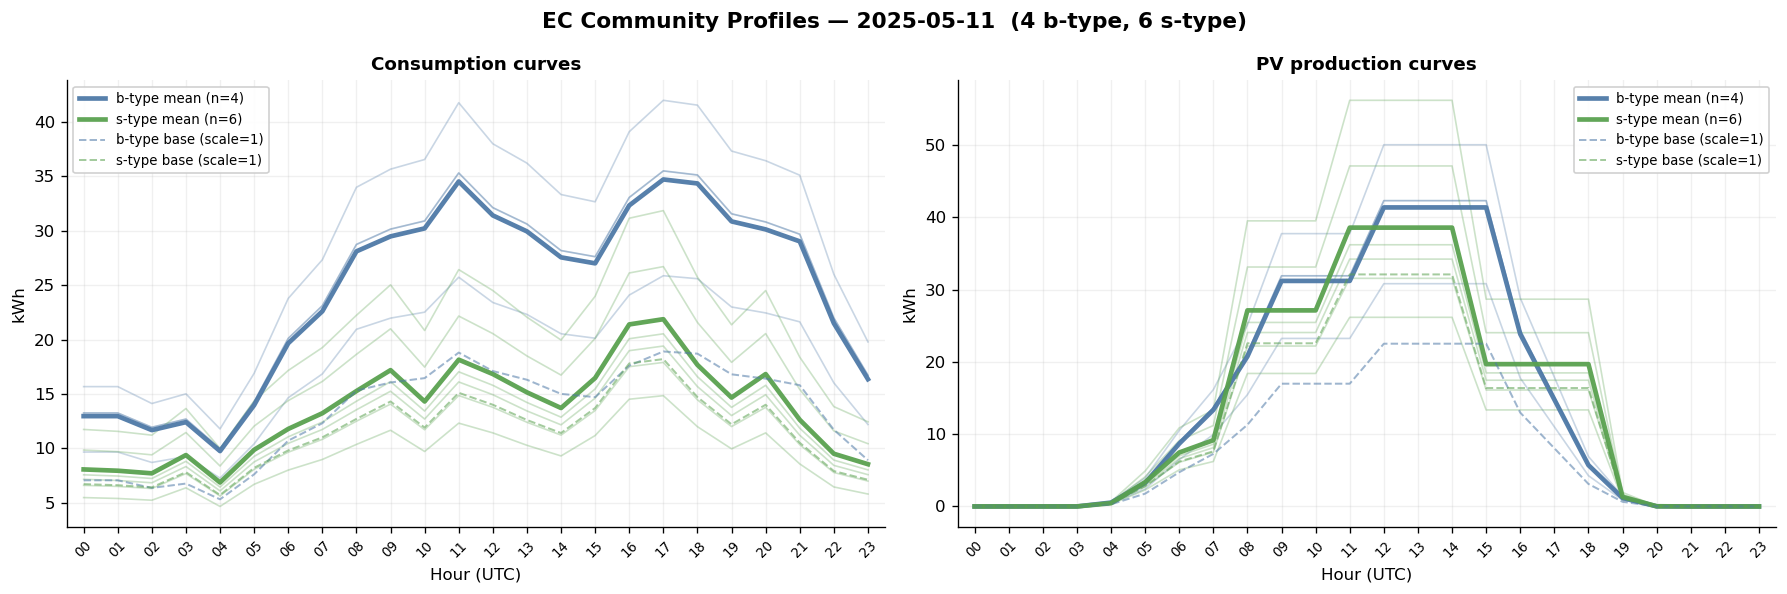

In [34]:
# ── EC community profiles — consumption & PV curves ──────────────────────────

def plot_ec_community_profiles(date=None):
    """
    Two side-by-side diagrams for a single day:
      Left  — Consumption curves: b-type in blue, s-type in green.
      Right — PV production curves: b-type in blue, s-type in green.
    Each EC is one line (base curve × scale factor). Mean curves per type
    are drawn bold. The unscaled base curves are shown as dashed references.
    """
    C_B      = '#4E79A7'   # blue  — type b
    C_S      = '#59A14F'   # green — type s
    ALPHA_EC = 0.30        # individual EC line transparency
    ALPHA_MEAN = 0.95

    # Use test_date if no date provided
    plot_date = date if date is not None else test_date

    day_b = df_b[df_b.index.date == plot_date].reset_index(drop=True)
    day_s = df_s[df_s.index.date == plot_date].reset_index(drop=True)

    if len(day_b) != 24 or len(day_s) != 24:
        print(f'Skipping {plot_date}: incomplete data ({len(day_b)}h b, {len(day_s)}h s)')
        return

    h = np.arange(24)

    # Build scaled curves per EC
    cons_b, cons_s = [], []
    pv_b,   pv_s   = [], []

    for ec in EC_LIST:
        src_cons = day_b['consumption'].values       if ec['base'] == 'b' else day_s['consumption'].values
        src_pv   = day_b['pv_production_kwh'].values if ec['base'] == 'b' else day_s['pv_production_kwh'].values
        scaled_cons = src_cons * ec['scale']
        scaled_pv   = src_pv   * ec['scale']
        if ec['base'] == 'b':
            cons_b.append(scaled_cons); pv_b.append(scaled_pv)
        else:
            cons_s.append(scaled_cons); pv_s.append(scaled_pv)

    fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=False)
    fig.suptitle(f'EC Community Profiles — {plot_date}  '
                 f'({sum(1 for e in EC_LIST if e["base"]=="b")} b-type, '
                 f'{sum(1 for e in EC_LIST if e["base"]=="s")} s-type)',
                 fontsize=13, fontweight='bold')

    for ax, title, curves_b, curves_s, base_b, base_s, ylabel in [
        (axes[0], 'Consumption curves',
         cons_b, cons_s,
         day_b['consumption'].values, day_s['consumption'].values,
         'kWh'),
        (axes[1], 'PV production curves',
         pv_b, pv_s,
         day_b['pv_production_kwh'].values, day_s['pv_production_kwh'].values,
         'kWh'),
    ]:
        # Individual EC lines
        for curve in curves_b:
            ax.plot(h, curve, color=C_B, alpha=ALPHA_EC, linewidth=1.0)
        for curve in curves_s:
            ax.plot(h, curve, color=C_S, alpha=ALPHA_EC, linewidth=1.0)

        # Mean lines per type (bold)
        if curves_b:
            ax.plot(h, np.mean(curves_b, axis=0), color=C_B,
                    linewidth=2.8, alpha=ALPHA_MEAN, label=f'b-type mean (n={len(curves_b)})')
        if curves_s:
            ax.plot(h, np.mean(curves_s, axis=0), color=C_S,
                    linewidth=2.8, alpha=ALPHA_MEAN, label=f's-type mean (n={len(curves_s)})')

        # Unscaled base curves as dashed reference
        ax.plot(h, base_b, color=C_B, linewidth=1.2, linestyle='--',
                alpha=0.55, label='b-type base (scale=1)')
        ax.plot(h, base_s, color=C_S, linewidth=1.2, linestyle='--',
                alpha=0.55, label='s-type base (scale=1)')

        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.set_ylabel(ylabel)
        ax.set_xlabel('Hour (UTC)')
        ax.set_xticks(range(24))
        ax.set_xticklabels([f'{hh:02d}' for hh in range(24)], rotation=45, fontsize=8)
        ax.set_xlim(-0.5, 23.5)
        ax.grid(alpha=0.18)
        ax.spines[['top', 'right']].set_visible(False)
        ax.legend(fontsize=8, framealpha=0.9)

    plt.tight_layout()
    plt.show()


plot_ec_community_profiles(test_date)

## 3 — Load market and frequency data

Column names in `combined_2025_with_frequency.csv`:
- `buy_price_inkl_vat_ore_kwh` / `sell_price_inkl_vat_ore_kwh` — spot prices in øre/kWh
- `price_ore_kwh_fcr_d_upp__d_1_early` / `..._late` — FCR-D Up capacity prices øre/kWh
- `price_ore_kwh_fcr_d_ned__d_1_early` / `..._late` — FCR-D Down capacity prices øre/kWh
- `y_act_fcrd_up` / `y_act_fcrd_down` — share of hour with f<49.9 Hz / f>50.1 Hz
- `data_quality_flag` — 0 = good, 1 = bad (15 min or partial hour)

All prices are converted from øre/kWh → DKK/kWh by dividing by 100.

In [35]:
df_raw = pd.read_csv(DATA_FILE, parse_dates=['hour_utc'])

# ── Convert prices: øre/kWh → DKK/kWh ──────────────────────────────────────
df_raw['buy_price_dkk']  = df_raw['buy_price_inkl_vat_ore_kwh']  / 100.0
df_raw['sell_price_dkk'] = df_raw['sell_price_inkl_vat_ore_kwh'] / 100.0

# FCR-D Up capacity prices
df_raw['fcrd_up_early_dkk'] = df_raw['price_ore_kwh_fcr_d_upp__d_1_early'].fillna(0.0).clip(lower=0) / 100.0
df_raw['fcrd_up_late_dkk']  = df_raw['price_ore_kwh_fcr_d_upp__d_1_late' ].fillna(0.0).clip(lower=0) / 100.0

# FCR-D Down capacity prices
df_raw['fcrd_dn_early_dkk'] = df_raw['price_ore_kwh_fcr_d_ned__d_1_early'].fillna(0.0).clip(lower=0) / 100.0
df_raw['fcrd_dn_late_dkk']  = df_raw['price_ore_kwh_fcr_d_ned__d_1_late' ].fillna(0.0).clip(lower=0) / 100.0

# Activation fractions (NaN → 0, clip to [0,1])
df_raw['y_act_up'] = df_raw['y_act_fcrd_up'  ].fillna(0.0).clip(0.0, 1.0)
df_raw['y_act_dn'] = df_raw['y_act_fcrd_down'].fillna(0.0).clip(0.0, 1.0)

# ── Filter to good-quality rows only ────────────────────────────────────────
df = df_raw[df_raw['data_quality_flag'] == 0].copy()
df['date'] = df['hour_utc'].dt.date

df_b = df[df['ec_id'] == 'b'].set_index('hour_utc').sort_index()
df_s = df[df['ec_id'] == 's'].set_index('hour_utc').sort_index()

print(f'EC b: {len(df_b)} hours  |  EC s: {len(df_s)} hours')
print(f'Date range: {df["date"].min()}  →  {df["date"].max()}')
print(f'FCR-D Up   early mean: {df_b["fcrd_up_early_dkk"].mean():.5f} DKK/kWh')
print(f'FCR-D Up   late  mean: {df_b["fcrd_up_late_dkk" ].mean():.5f} DKK/kWh')
print(f'FCR-D Down early mean: {df_b["fcrd_dn_early_dkk"].mean():.5f} DKK/kWh')
print(f'FCR-D Down late  mean: {df_b["fcrd_dn_late_dkk" ].mean():.5f} DKK/kWh')
print(f'y_act Up   mean: {df_b["y_act_up"].mean():.6f}')
print(f'y_act Down mean: {df_b["y_act_dn"].mean():.6f}')

EC b: 8745 hours  |  EC s: 8745 hours
Date range: 2025-01-01  →  2025-12-31
FCR-D Up   early mean: 0.04382 DKK/kWh
FCR-D Up   late  mean: 0.04757 DKK/kWh
FCR-D Down early mean: 0.03665 DKK/kWh
FCR-D Down late  mean: 0.06065 DKK/kWh
y_act Up   mean: 0.000270
y_act Down mean: 0.000243


## 4 — Per-EC, per-day data builder

Returns a tuple `(day_early, day_late)` for each date:
- `day_early`: noisy forecasts simulating what is known at D-1 00:30 (Early GCT).
  Noise is added to PV, demand, and y_act. Prices use the **early auction prices**.
- `day_late`: true realised values known at D-1 18:00 (Late GCT).
  Prices use the **late auction prices**.

In practice the noise represents the improvement in forecast accuracy
between the two gate closure times.

In [36]:
def get_day_per_ec(date):
    """Build early + late per-EC day dicts. Returns None if <24 rows for either type."""
    day_b = df_b[df_b.index.date == date].reset_index(drop=True)
    day_s = df_s[df_s.index.date == date].reset_index(drop=True)
    if len(day_b) != 24 or len(day_s) != 24:
        return None

    rng_day = np.random.default_rng(hash(str(date)) % (2**31))

    # ── True (late) load and PV ─────────────────────────────────────────
    D_true  = {}
    PV_true = {}
    for ec in EC_LIST:
        src = day_b if ec['base'] == 'b' else day_s
        D_true [ec['id']] = src['consumption'      ].values * ec['scale']
        PV_true[ec['id']] = src['pv_production_kwh'].values * ec['scale']

    y_act_up_true = day_b['y_act_up'].values
    y_act_dn_true = day_b['y_act_dn'].values

    # ── Noisy (early) load and PV ───────────────────────────────────────
    D_noisy  = {}
    PV_noisy = {}
    for ec in EC_LIST:
        D_noisy [ec['id']] = np.maximum(0,
            D_true[ec['id']]  * (1 + rng_day.normal(0, EARLY_D_NOISE_STD,  24)))
        PV_noisy[ec['id']] = np.maximum(0,
            PV_true[ec['id']] * (1 + rng_day.normal(0, EARLY_PV_NOISE_STD, 24)))

    y_act_up_noisy = np.clip(y_act_up_true + rng_day.normal(0, EARLY_ACT_NOISE_STD, 24), 0, 1)
    y_act_dn_noisy = np.clip(y_act_dn_true + rng_day.normal(0, EARLY_ACT_NOISE_STD, 24), 0, 1)

    # ── Assemble dicts ──────────────────────────────────────────────────
    day_early = {
        'date':          date,
        'D':             D_noisy,
        'PV':            PV_noisy,
        'buy_price':     day_b['buy_price_dkk'   ].values,
        'sell_price':    day_b['sell_price_dkk'  ].values,
        'fcrd_up_price': day_b['fcrd_up_early_dkk'].values,
        'fcrd_dn_price': day_b['fcrd_dn_early_dkk'].values,
        'y_act_up':      y_act_up_noisy,
        'y_act_dn':      y_act_dn_noisy,
    }

    day_late = {
        'date':               date,
        'D':                  D_true,
        'PV':                 PV_true,
        'buy_price':          day_b['buy_price_dkk'    ].values,
        'sell_price':         day_b['sell_price_dkk'   ].values,
        'fcrd_up_price_late': day_b['fcrd_up_late_dkk' ].values,
        'fcrd_dn_price_late': day_b['fcrd_dn_late_dkk' ].values,
        'fcrd_up_price_early':day_b['fcrd_up_early_dkk'].values,
        'fcrd_dn_price_early':day_b['fcrd_dn_early_dkk'].values,
        'y_act_up':           y_act_up_true,
        'y_act_dn':           y_act_dn_true,
    }
    return day_early, day_late

# ── Smoke test ───────────────────────────────────────────────────────────────
all_dates = sorted(set(df_b.index.date))
_r = get_day_per_ec(test_date)
assert _r is not None, f'No data for {test_date}'
_de, _dl = _r
print(f'Test date {test_date}: early D={sum(v.sum() for v in _de["D"].values()):.1f} kWh  '
      f'late D={sum(v.sum() for v in _dl["D"].values()):.1f} kWh')
print(f'Available dates: {len(all_dates)}  (days with exactly 24h per type)')

Test date 2025-05-11: early D=4274.1 kWh  late D=4283.0 kWh
Available dates: 365  (days with exactly 24h per type)


## 5 — Model builder: Early auction MILP

Optimises FCR-D Up + Down reservations given early (noisy) forecasts.
Constraint tags mirror the LaTeX document (E-obj) → (E-11).
Identical in structure to NB05's `build_btm_bidir`.

In [37]:
def build_early(day, fcrd=True):
    #Early-auction FCR-D MILP (Program 1).  fcrd=False → base battery only.
    m = ConcreteModel()
    T = list(range(1, 25))
    m.E = Set(initialize=EC_IDS)
    m.T = Set(initialize=T)

    # ── Parameters ──────────────────────────────────────────────────────
    m.D  = Param(m.E, m.T, initialize={(e,t): day['D' ][e][t-1] for e in EC_IDS for t in T})
    m.PV = Param(m.E, m.T, initialize={(e,t): day['PV'][e][t-1] for e in EC_IDS for t in T})
    m.b_max = Param(m.E, initialize={e: EC_BY_ID[e]['b_max'] for e in EC_IDS})
    m.s_max = Param(m.E, initialize={e: EC_BY_ID[e]['s_max'] for e in EC_IDS})
    m.eta   = Param(m.E, initialize={e: EC_BY_ID[e]['eta'  ] for e in EC_IDS})
    m.buy   = Param(m.T, initialize={t: day['buy_price' ][t-1] for t in T})
    m.sell  = Param(m.T, initialize={t: day['sell_price'][t-1] for t in T})
    if fcrd:
        m.lam_up   = Param(m.T, initialize={t: day['fcrd_up_price'][t-1] for t in T})
        m.lam_dn   = Param(m.T, initialize={t: day['fcrd_dn_price'][t-1] for t in T})
        m.y_act_up = Param(m.T, initialize={t: day['y_act_up'     ][t-1] for t in T})
        m.y_act_dn = Param(m.T, initialize={t: day['y_act_dn'     ][t-1] for t in T})

    # ── Decision variables ───────────────────────────────────────────────
    m.p_im  = Var(m.E, m.T, domain=NonNegativeReals)
    m.p_ex  = Var(m.E, m.T, domain=NonNegativeReals)
    m.p_net = Var(m.E, m.T, domain=Reals)
    m.b_ch  = Var(m.E, m.T, domain=NonNegativeReals)
    m.b_dis = Var(m.E, m.T, domain=NonNegativeReals)
    m.soc   = Var(m.E, m.T, domain=NonNegativeReals)
    if fcrd:
        m.p_res_up = Var(m.E, m.T, domain=NonNegativeReals)
        m.p_res_dn = Var(m.E, m.T, domain=NonNegativeReals)
        m.p_act_up = Var(m.E, m.T, domain=NonNegativeReals)
        m.p_act_dn = Var(m.E, m.T, domain=NonNegativeReals)
        m.z_up = Var(m.T, domain=Binary)
        m.z_dn = Var(m.T, domain=Binary)

    # ── (E-obj) Objective ────────────────────────────────────────────────
    if fcrd:
        m.obj = Objective(sense=minimize, expr=sum(
              m.buy[t]  * (sum(m.p_im[e,t] for e in m.E) - sum(m.p_act_dn[e,t] for e in m.E))
            - m.sell[t] * (sum(m.p_ex[e,t] for e in m.E) - sum(m.p_act_up[e,t] for e in m.E))
            - m.lam_up[t] * sum(m.p_res_up[e,t] for e in m.E)
            - m.lam_dn[t] * sum(m.p_res_dn[e,t] for e in m.E)
            for t in m.T))
    else:
        m.obj = Objective(sense=minimize, expr=sum(
            m.buy[t]*m.p_im[e,t] - m.sell[t]*m.p_ex[e,t]
            for e in m.E for t in m.T))

    # ── (E-1) Net power balance ──────────────────────────────────────────
    m.c_m1b = Constraint(m.E, m.T,
        rule=lambda m,e,t: m.p_net[e,t] - m.p_im[e,t] + m.p_ex[e,t] == 0)

    # ── (E-4) Battery power balance ──────────────────────────────────────
    def _c2i(m,e,t):
        rhs = m.p_net[e,t] + m.PV[e,t] - m.D[e,t] - m.b_ch[e,t] + m.b_dis[e,t]
        if fcrd: rhs = rhs - m.p_act_dn[e,t] + m.p_act_up[e,t]
        return rhs == 0
    m.c_c2i = Constraint(m.E, m.T, rule=_c2i)

    if fcrd:
        # ── (E-5) Activation linkers ─────────────────────────────────────
        m.c_c3b_up = Constraint(m.E, m.T,
            rule=lambda m,e,t: m.p_act_up[e,t] == m.y_act_up[t] * m.p_res_up[e,t])
        m.c_c3b_dn = Constraint(m.E, m.T,
            rule=lambda m,e,t: m.p_act_dn[e,t] == m.y_act_dn[t] * m.p_res_dn[e,t])

    # ── (E-6a) SOC dynamics t ≥ 2 ───────────────────────────────────────
    def _m2j(m,e,t):
        if t == 1: return Constraint.Skip
        gain  = m.b_ch[e,t]  + (m.p_act_dn[e,t] if fcrd else 0)
        drain = m.b_dis[e,t] + (m.p_act_up[e,t] if fcrd else 0)
        return m.soc[e,t] == m.soc[e,t-1] + m.eta[e]*gain - (1/m.eta[e])*drain
    m.c_m2j = Constraint(m.E, m.T, rule=_m2j)

    # ── (E-6b) SOC at t=1 ───────────────────────────────────────────────
    def _m2k(m,e):
        gain  = m.b_ch[e,1]  + (m.p_act_dn[e,1] if fcrd else 0)
        drain = m.b_dis[e,1] + (m.p_act_up[e,1] if fcrd else 0)
        return m.soc[e,1] == SOC_INIT_FRAC*m.s_max[e] + m.eta[e]*gain - (1/m.eta[e])*drain
    m.c_m2k = Constraint(m.E, rule=_m2k)

    # ── (E-6c) Terminal SOC ──────────────────────────────────────────────
    m.c_c1l = Constraint(m.E,
        rule=lambda m,e: m.soc[e,24] == SOC_INIT_FRAC*m.s_max[e])

    if fcrd:
        # ── (E-7) SOC sustain ─────────────────────────────────────────────
        m.c_m13_up = Constraint(m.E, m.T,
            rule=lambda m,e,t: m.soc[e,t] >= (T_SUSTAIN/m.eta[e])*m.p_res_up[e,t])
        m.c_m13_dn = Constraint(m.E, m.T,
            rule=lambda m,e,t: (m.s_max[e]-m.soc[e,t]) >= T_SUSTAIN*m.eta[e]*m.p_res_dn[e,t])
        # ── (E-8) Power limits ────────────────────────────────────────────
        m.c_c1m = Constraint(m.E, m.T,
            rule=lambda m,e,t: m.b_ch[e,t]  + m.p_res_dn[e,t] <= m.b_max[e])
        m.c_c3c = Constraint(m.E, m.T,
            rule=lambda m,e,t: m.b_dis[e,t] + m.p_res_up[e,t] <= m.b_max[e])
    else:
        m.c_bch  = Constraint(m.E, m.T, rule=lambda m,e,t: m.b_ch[e,t]  <= m.b_max[e])
        m.c_bdis = Constraint(m.E, m.T, rule=lambda m,e,t: m.b_dis[e,t] <= m.b_max[e])

    # ── SOC ≤ S̄ (always) ────────────────────────────────────────────────
    m.c_soc_max = Constraint(m.E, m.T,
        rule=lambda m,e,t: m.soc[e,t] <= m.s_max[e])

    if fcrd:
        # ── (E-9) SOC headroom ────────────────────────────────────────────
        m.c_c3d_up = Constraint(m.E, m.T,
            rule=lambda m,e,t: m.soc[e,t] >= m.p_res_up[e,t])
        m.c_c3d_dn = Constraint(m.E, m.T,
            rule=lambda m,e,t: (m.s_max[e]-m.soc[e,t]) >= m.p_res_dn[e,t])
        # ── (E-10) Min-bid disjunctions (portfolio level) ─────────────────
        m.c_m1_up_lo = Constraint(m.T,
            rule=lambda m,t: P_MIN*m.z_up[t] <= sum(m.p_res_up[e,t] for e in m.E))
        m.c_m1_up_hi = Constraint(m.T,
            rule=lambda m,t: sum(m.p_res_up[e,t] for e in m.E) <= P_BAR_AGG*m.z_up[t])
        m.c_m1_dn_lo = Constraint(m.T,
            rule=lambda m,t: P_MIN*m.z_dn[t] <= sum(m.p_res_dn[e,t] for e in m.E))
        m.c_m1_dn_hi = Constraint(m.T,
            rule=lambda m,t: sum(m.p_res_dn[e,t] for e in m.E) <= P_BAR_AGG*m.z_dn[t])
    return m


def solve_model(m):
    return SolverFactory(SOLVER).solve(m, tee=False)

## 6 — Model builder: Late auction MILP

Takes early-accepted quantities as fixed parameters and optimises **adjustments**:
- $c_{e,t}^{\uparrow/\downarrow}$ — cancellation (negative bid, $\leq$ accepted)
- $a_{e,t}^{\uparrow/\downarrow}$ — top-up (new positive bid)

Final reservation: $p^{res} = \hat{p}^{acc} - c + a$.

Buyback price per BSP guide §3.6.3:
$\lambda^{bb} = \max(\lambda^{early\_clearing}, \lambda^{late\_clearing\_forecast})$

All physical constraints are re-evaluated under the updated late forecasts.

In [38]:
def extract_early_accepted(m_early):
    #Pull accepted (offered) reservation quantities from a solved early model.
    acc_up, acc_dn = {}, {}
    for e in EC_IDS:
        for t in range(1, 25):
            acc_up[(e,t)] = max(0.0, value(m_early.p_res_up[e,t]))
            acc_dn[(e,t)] = max(0.0, value(m_early.p_res_dn[e,t]))
    return acc_up, acc_dn


def build_late(day_late, early_acc_up, early_acc_dn,
               early_clearing_up, early_clearing_dn):
    m = ConcreteModel()
    T = list(range(1, 25))
    m.E = Set(initialize=EC_IDS)
    m.T = Set(initialize=T)

    # ── Parameters ──────────────────────────────────────────────────────
    m.D  = Param(m.E, m.T, initialize={(e,t): day_late['D' ][e][t-1] for e in EC_IDS for t in T})
    m.PV = Param(m.E, m.T, initialize={(e,t): day_late['PV'][e][t-1] for e in EC_IDS for t in T})
    m.b_max = Param(m.E, initialize={e: EC_BY_ID[e]['b_max'] for e in EC_IDS})
    m.s_max = Param(m.E, initialize={e: EC_BY_ID[e]['s_max'] for e in EC_IDS})
    m.eta   = Param(m.E, initialize={e: EC_BY_ID[e]['eta'  ] for e in EC_IDS})
    m.buy   = Param(m.T, initialize={t: day_late['buy_price' ][t-1] for t in T})
    m.sell  = Param(m.T, initialize={t: day_late['sell_price'][t-1] for t in T})

    m.lam_up_late  = Param(m.T, initialize={t: day_late['fcrd_up_price_late'][t-1] for t in T})
    m.lam_dn_late  = Param(m.T, initialize={t: day_late['fcrd_dn_price_late'][t-1] for t in T})
    m.lam_up_early = Param(m.T, initialize={t: early_clearing_up[t-1] for t in T})
    m.lam_dn_early = Param(m.T, initialize={t: early_clearing_dn[t-1] for t in T})

    # Buyback = max(early clearing, late forecast) — evaluated as parameter before solve
    m.lam_up_bb = Param(m.T, initialize={
        t: max(early_clearing_up[t-1], day_late['fcrd_up_price_late'][t-1]) for t in T})
    m.lam_dn_bb = Param(m.T, initialize={
        t: max(early_clearing_dn[t-1], day_late['fcrd_dn_price_late'][t-1]) for t in T})

    # Early accepted quantities (fixed)
    m.p_acc_up = Param(m.E, m.T, initialize=early_acc_up)
    m.p_acc_dn = Param(m.E, m.T, initialize=early_acc_dn)

    m.y_act_up = Param(m.T, initialize={t: day_late['y_act_up'][t-1] for t in T})
    m.y_act_dn = Param(m.T, initialize={t: day_late['y_act_dn'][t-1] for t in T})

    # ── Decision variables ───────────────────────────────────────────────
    m.p_im  = Var(m.E, m.T, domain=NonNegativeReals)
    m.p_ex  = Var(m.E, m.T, domain=NonNegativeReals)
    m.p_net = Var(m.E, m.T, domain=Reals)
    m.b_ch  = Var(m.E, m.T, domain=NonNegativeReals)
    m.b_dis = Var(m.E, m.T, domain=NonNegativeReals)
    m.soc   = Var(m.E, m.T, domain=NonNegativeReals)

    m.c_up = Var(m.E, m.T, domain=NonNegativeReals)   # cancellation Up
    m.c_dn = Var(m.E, m.T, domain=NonNegativeReals)   # cancellation Down
    m.a_up = Var(m.E, m.T, domain=NonNegativeReals)   # top-up Up
    m.a_dn = Var(m.E, m.T, domain=NonNegativeReals)   # top-up Down

    m.p_res_up = Var(m.E, m.T, domain=NonNegativeReals)  # final reservation Up
    m.p_res_dn = Var(m.E, m.T, domain=NonNegativeReals)  # final reservation Down
    m.p_act_up = Var(m.E, m.T, domain=NonNegativeReals)
    m.p_act_dn = Var(m.E, m.T, domain=NonNegativeReals)

    m.z_up = Var(m.T, domain=Binary)   # final total min-bid indicator
    m.z_dn = Var(m.T, domain=Binary)
    m.w_up = Var(m.T, domain=Binary)   # top-up min-bid indicator
    m.w_dn = Var(m.T, domain=Binary)

    # ── (L-1) Reservation linking ────────────────────────────────────────
    m.c_l1_up = Constraint(m.E, m.T,
        rule=lambda m,e,t: m.p_res_up[e,t] == m.p_acc_up[e,t] - m.c_up[e,t] + m.a_up[e,t])
    m.c_l1_dn = Constraint(m.E, m.T,
        rule=lambda m,e,t: m.p_res_dn[e,t] == m.p_acc_dn[e,t] - m.c_dn[e,t] + m.a_dn[e,t])

    # ── (L-2) Cancellation ≤ accepted ────────────────────────────────────
    m.c_l2_up = Constraint(m.E, m.T,
        rule=lambda m,e,t: m.c_up[e,t] <= m.p_acc_up[e,t])
    m.c_l2_dn = Constraint(m.E, m.T,
        rule=lambda m,e,t: m.c_dn[e,t] <= m.p_acc_dn[e,t])

    # ── No simultaneous cancel + top-up in same hour and direction ───────
    # Per BSP guide §3.4: negative bids cannot be combined with other bids
    m.c_no_mix_up = Constraint(m.E, m.T,
        rule=lambda m,e,t: m.c_up[e,t] <= m.p_acc_up[e,t] * (1 - m.w_up[t]))
    m.c_no_mix_dn = Constraint(m.E, m.T,
        rule=lambda m,e,t: m.c_dn[e,t] <= m.p_acc_dn[e,t] * (1 - m.w_dn[t]))

    # ── (L-obj) Objective ────────────────────────────────────────────────
    m.obj = Objective(sense=minimize, expr=sum(
        # Spot market (uses late forecasts for D and PV)
          m.buy[t]  * (sum(m.p_im[e,t] for e in m.E) - sum(m.p_act_dn[e,t] for e in m.E))
        - m.sell[t] * (sum(m.p_ex[e,t] for e in m.E) - sum(m.p_act_up[e,t] for e in m.E))
        # Early revenue (constant — retained for total-profit accounting)
        - m.lam_up_early[t] * sum(m.p_acc_up[e,t] for e in m.E)
        - m.lam_dn_early[t] * sum(m.p_acc_dn[e,t] for e in m.E)
        # Cancellation cost at buyback price
        + m.lam_up_bb[t] * sum(m.c_up[e,t] for e in m.E)
        + m.lam_dn_bb[t] * sum(m.c_dn[e,t] for e in m.E)
        # Top-up revenue at late price
        - m.lam_up_late[t] * sum(m.a_up[e,t] for e in m.E)
        - m.lam_dn_late[t] * sum(m.a_dn[e,t] for e in m.E)
        for t in m.T))

    # ── Physical constraints (same structure as early, late forecasts) ───
    m.c_m1b = Constraint(m.E, m.T,
        rule=lambda m,e,t: m.p_net[e,t] - m.p_im[e,t] + m.p_ex[e,t] == 0)

    m.c_c2i = Constraint(m.E, m.T,
        rule=lambda m,e,t: (m.p_net[e,t] + m.PV[e,t] - m.D[e,t]
            - m.b_ch[e,t] - m.p_act_dn[e,t]
            + m.b_dis[e,t] + m.p_act_up[e,t]) == 0)

    m.c_c3b_up = Constraint(m.E, m.T,
        rule=lambda m,e,t: m.p_act_up[e,t] == m.y_act_up[t]*m.p_res_up[e,t])
    m.c_c3b_dn = Constraint(m.E, m.T,
        rule=lambda m,e,t: m.p_act_dn[e,t] == m.y_act_dn[t]*m.p_res_dn[e,t])

    def _m2j(m,e,t):
        if t == 1: return Constraint.Skip
        gain  = m.b_ch[e,t]  + m.p_act_dn[e,t]
        drain = m.b_dis[e,t] + m.p_act_up[e,t]
        return m.soc[e,t] == m.soc[e,t-1] + m.eta[e]*gain - (1/m.eta[e])*drain
    m.c_m2j = Constraint(m.E, m.T, rule=_m2j)

    def _m2k(m,e):
        gain  = m.b_ch[e,1] + m.p_act_dn[e,1]
        drain = m.b_dis[e,1] + m.p_act_up[e,1]
        return m.soc[e,1] == SOC_INIT_FRAC*m.s_max[e] + m.eta[e]*gain - (1/m.eta[e])*drain
    m.c_m2k = Constraint(m.E, rule=_m2k)

    m.c_c1l = Constraint(m.E,
        rule=lambda m,e: m.soc[e,24] == SOC_INIT_FRAC*m.s_max[e])

    m.c_m13_up = Constraint(m.E, m.T,
        rule=lambda m,e,t: m.soc[e,t] >= (T_SUSTAIN/m.eta[e])*m.p_res_up[e,t])
    m.c_m13_dn = Constraint(m.E, m.T,
        rule=lambda m,e,t: (m.s_max[e]-m.soc[e,t]) >= T_SUSTAIN*m.eta[e]*m.p_res_dn[e,t])

    m.c_c1m = Constraint(m.E, m.T,
        rule=lambda m,e,t: m.b_ch[e,t]  + m.p_res_dn[e,t] <= m.b_max[e])
    m.c_c3c = Constraint(m.E, m.T,
        rule=lambda m,e,t: m.b_dis[e,t] + m.p_res_up[e,t] <= m.b_max[e])

    m.c_soc_max = Constraint(m.E, m.T,
        rule=lambda m,e,t: m.soc[e,t] <= m.s_max[e])
    m.c_c3d_up = Constraint(m.E, m.T,
        rule=lambda m,e,t: m.soc[e,t] >= m.p_res_up[e,t])
    m.c_c3d_dn = Constraint(m.E, m.T,
        rule=lambda m,e,t: (m.s_max[e]-m.soc[e,t]) >= m.p_res_dn[e,t])

    # ── (L-5) Min-bid for top-ups ────────────────────────────────────────
    m.c_l5_up_lo = Constraint(m.T,
        rule=lambda m,t: P_MIN*m.w_up[t] <= sum(m.a_up[e,t] for e in m.E))
    m.c_l5_up_hi = Constraint(m.T,
        rule=lambda m,t: sum(m.a_up[e,t] for e in m.E) <= P_BAR_AGG*m.w_up[t])
    m.c_l5_dn_lo = Constraint(m.T,
        rule=lambda m,t: P_MIN*m.w_dn[t] <= sum(m.a_dn[e,t] for e in m.E))
    m.c_l5_dn_hi = Constraint(m.T,
        rule=lambda m,t: sum(m.a_dn[e,t] for e in m.E) <= P_BAR_AGG*m.w_dn[t])

    # ── (L-6) Min-bid for final total reservation ────────────────────────
    m.c_l6_up_lo = Constraint(m.T,
        rule=lambda m,t: P_MIN*m.z_up[t] <= sum(m.p_res_up[e,t] for e in m.E))
    m.c_l6_up_hi = Constraint(m.T,
        rule=lambda m,t: sum(m.p_res_up[e,t] for e in m.E) <= P_BAR_AGG*m.z_up[t])
    m.c_l6_dn_lo = Constraint(m.T,
        rule=lambda m,t: P_MIN*m.z_dn[t] <= sum(m.p_res_dn[e,t] for e in m.E))
    m.c_l6_dn_hi = Constraint(m.T,
        rule=lambda m,t: sum(m.p_res_dn[e,t] for e in m.E) <= P_BAR_AGG*m.z_dn[t])

    return m

## 7 — Result extraction

In [39]:
def extract_early_day(m, day, has_fcrd=True):
    rows = []
    for t in range(1, 25):
        p_im  = sum(value(m.p_im [e,t]) for e in EC_IDS)
        p_ex  = sum(value(m.p_ex [e,t]) for e in EC_IDS)
        b_ch  = sum(value(m.b_ch [e,t]) for e in EC_IDS)
        b_dis = sum(value(m.b_dis[e,t]) for e in EC_IDS)
        soc   = sum(value(m.soc  [e,t]) for e in EC_IDS)
        D_agg = sum(day['D' ][e][t-1] for e in EC_IDS)
        PV_agg= sum(day['PV'][e][t-1] for e in EC_IDS)
        row = {
            'date': day['date'], 'hour': t-1,
            'D_agg': D_agg, 'PV_agg': PV_agg,
            'p_im_agg': p_im, 'p_ex_agg': p_ex,
            'b_ch_agg': b_ch, 'b_dis_agg': b_dis, 'soc_agg': soc,
            'buy_price':  day['buy_price' ][t-1],
            'sell_price': day['sell_price'][t-1],
        }
        if has_fcrd:
            res_up = sum(value(m.p_res_up[e,t]) for e in EC_IDS)
            res_dn = sum(value(m.p_res_dn[e,t]) for e in EC_IDS)
            act_up = sum(value(m.p_act_up[e,t]) for e in EC_IDS)
            act_dn = sum(value(m.p_act_dn[e,t]) for e in EC_IDS)
            row.update({
                'p_res_up_agg':  res_up,
                'p_res_dn_agg':  res_dn,
                'p_act_up_agg':  act_up,
                'p_act_dn_agg':  act_dn,
                'fcrd_up_price': day['fcrd_up_price'][t-1],
                'fcrd_dn_price': day['fcrd_dn_price'][t-1],
                'y_act_up':      day['y_act_up'][t-1],
                'y_act_dn':      day['y_act_dn'][t-1],
                'rev_up':        day['fcrd_up_price'][t-1] * res_up,
                'rev_dn':        day['fcrd_dn_price'][t-1] * res_dn,
                'z_up': int(round(value(m.z_up[t]))),
                'z_dn': int(round(value(m.z_dn[t]))),
            })
            row['arb_cost'] = (day['buy_price'][t-1]  * (p_im - act_dn)
                             - day['sell_price'][t-1] * (p_ex - act_up))
        else:
            row['arb_cost'] = day['buy_price'][t-1]*p_im - day['sell_price'][t-1]*p_ex
        rows.append(row)
    return pd.DataFrame(rows)


def extract_late_day(m, day_late, early_clearing_up, early_clearing_dn):
    rows = []
    for t in range(1, 25):
        p_im  = sum(value(m.p_im [e,t]) for e in EC_IDS)
        p_ex  = sum(value(m.p_ex [e,t]) for e in EC_IDS)
        b_ch  = sum(value(m.b_ch [e,t]) for e in EC_IDS)
        b_dis = sum(value(m.b_dis[e,t]) for e in EC_IDS)
        soc   = sum(value(m.soc  [e,t]) for e in EC_IDS)
        res_up = sum(value(m.p_res_up[e,t]) for e in EC_IDS)
        res_dn = sum(value(m.p_res_dn[e,t]) for e in EC_IDS)
        act_up = sum(value(m.p_act_up[e,t]) for e in EC_IDS)
        act_dn = sum(value(m.p_act_dn[e,t]) for e in EC_IDS)
        c_up   = sum(value(m.c_up[e,t]) for e in EC_IDS)
        c_dn   = sum(value(m.c_dn[e,t]) for e in EC_IDS)
        a_up   = sum(value(m.a_up[e,t]) for e in EC_IDS)
        a_dn   = sum(value(m.a_dn[e,t]) for e in EC_IDS)
        acc_up = sum(value(m.p_acc_up[e,t]) for e in EC_IDS)
        acc_dn = sum(value(m.p_acc_dn[e,t]) for e in EC_IDS)

        lam_up_late = day_late['fcrd_up_price_late'][t-1]
        lam_dn_late = day_late['fcrd_dn_price_late'][t-1]
        bb_up = max(early_clearing_up[t-1], lam_up_late)
        bb_dn = max(early_clearing_dn[t-1], lam_dn_late)

        rev_early_up   = early_clearing_up[t-1] * acc_up
        rev_early_dn   = early_clearing_dn[t-1] * acc_dn
        cost_cancel_up = bb_up * c_up
        cost_cancel_dn = bb_dn * c_dn
        rev_topup_up   = lam_up_late * a_up
        rev_topup_dn   = lam_dn_late * a_dn

        row = {
            'date': day_late['date'], 'hour': t-1,
            'D_agg': sum(day_late['D'][e][t-1] for e in EC_IDS),
            'PV_agg': sum(day_late['PV'][e][t-1] for e in EC_IDS),
            'p_im_agg': p_im, 'p_ex_agg': p_ex,
            'b_ch_agg': b_ch, 'b_dis_agg': b_dis, 'soc_agg': soc,
            'buy_price': day_late['buy_price'][t-1],
            'sell_price': day_late['sell_price'][t-1],
            'p_res_up_final': res_up, 'p_res_dn_final': res_dn,
            'p_act_up_agg': act_up,   'p_act_dn_agg': act_dn,
            'p_acc_up_early': acc_up, 'p_acc_dn_early': acc_dn,
            'cancel_up': c_up,  'cancel_dn': c_dn,
            'topup_up':  a_up,  'topup_dn':  a_dn,
            'fcrd_up_price_early': early_clearing_up[t-1],
            'fcrd_dn_price_early': early_clearing_dn[t-1],
            'fcrd_up_price_late':  lam_up_late,
            'fcrd_dn_price_late':  lam_dn_late,
            'buyback_up': bb_up,  'buyback_dn': bb_dn,
            'rev_early_up': rev_early_up,  'rev_early_dn': rev_early_dn,
            'cost_cancel_up': cost_cancel_up, 'cost_cancel_dn': cost_cancel_dn,
            'rev_topup_up': rev_topup_up,  'rev_topup_dn': rev_topup_dn,
            'rev_total_up': rev_early_up - cost_cancel_up + rev_topup_up,
            'rev_total_dn': rev_early_dn - cost_cancel_dn + rev_topup_dn,
            'y_act_up': day_late['y_act_up'][t-1],
            'y_act_dn': day_late['y_act_dn'][t-1],
            'z_up': int(round(value(m.z_up[t]))),
            'z_dn': int(round(value(m.z_dn[t]))),
        }
        row['arb_cost'] = (day_late['buy_price'][t-1]  * (p_im - act_dn)
                         - day_late['sell_price'][t-1] * (p_ex - act_up))
        rows.append(row)
    return pd.DataFrame(rows)

## 8 — Single-day validation

Sequential pipeline: base → early → extract accepted → late.

Checks:
- Constraint (L-2): cancel ≤ accepted for all (e, t).
- Constraint (L-1): p_res = p_acc − c + a for all (e, t).
- (E-5) activation linkers hold post-solve.
- (E-10) / (L-5) / (L-6) min-bid disjunctions hold.
- Manual SOC reproduction matches Pyomo over 24 h.

In [40]:
_de, _dl = get_day_per_ec(test_date)

m_base  = build_early(_de, fcrd=False); solve_model(m_base)
m_early = build_early(_de, fcrd=True ); solve_model(m_early)
df_early_t = extract_early_day(m_early, _de, has_fcrd=True)

early_acc_up, early_acc_dn = extract_early_accepted(m_early)
clr_up = _de['fcrd_up_price']   # early clearing prices = early bid prices (price-taker)
clr_dn = _de['fcrd_dn_price']

m_late = build_late(_dl, early_acc_up, early_acc_dn, clr_up, clr_dn)
solve_model(m_late)
df_late_t = extract_late_day(m_late, _dl, clr_up, clr_dn)

print(f'Day {test_date} — validation')
print('='*65)
print(f'  Base obj:  {value(m_base.obj ):>12.4f} DKK  (no FCR-D)')
print(f'  Early obj: {value(m_early.obj):>12.4f} DKK  (early FCR-D, noisy fcast)')
print(f'  Late obj:  {value(m_late.obj ):>12.4f} DKK  (late adjust,  true fcast)')
print()

# 1. Cancel ≤ accepted (L-2)
viol_cancel = sum(1 for e in EC_IDS for t in range(1,25)
    if value(m_late.c_up[e,t]) > value(m_late.p_acc_up[e,t]) + 1e-4
    or value(m_late.c_dn[e,t]) > value(m_late.p_acc_dn[e,t]) + 1e-4)
print(f'  (L-2) cancel ≤ accepted violations: {viol_cancel}')

# 2. Linking (L-1)
viol_link = sum(1 for e in EC_IDS for t in range(1,25)
    if abs(value(m_late.p_res_up[e,t])
           - (value(m_late.p_acc_up[e,t]) - value(m_late.c_up[e,t]) + value(m_late.a_up[e,t]))) > 1e-4)
print(f'  (L-1) reservation linking violations: {viol_link}')

# 3. Activation linkers (E-5)
viol_act = sum(1 for e in EC_IDS for t in range(1,25)
    if abs(value(m_early.p_act_up[e,t]) - _de['y_act_up'][t-1]*value(m_early.p_res_up[e,t])) > 1e-5
    or abs(value(m_early.p_act_dn[e,t]) - _de['y_act_dn'][t-1]*value(m_early.p_res_dn[e,t])) > 1e-5)
print(f'  (E-5) activation linker violations (early): {viol_act}')

# 4. Manual SOC check (early model, first EC)
e0 = EC_IDS[0]; eta0 = EC_BY_ID[e0]['eta']; mism = 0
soc_chk = SOC_INIT_FRAC * EC_BY_ID[e0]['s_max']
for t in range(1,25):
    soc_chk = (soc_chk
        + eta0*(value(m_early.b_ch[e0,t]) + value(m_early.p_act_dn[e0,t]))
        - (1/eta0)*(value(m_early.b_dis[e0,t]) + value(m_early.p_act_up[e0,t])))
    if abs(soc_chk - value(m_early.soc[e0,t])) > 1e-3: mism += 1
print(f'  Manual SOC match (early, {e0}): mismatches = {mism}')

# 5. Min-bid (early)
ok_e = all(
    (int(round(value(m_early.z_up[t])))==1) == (sum(value(m_early.p_res_up[e,t]) for e in EC_IDS) >= P_MIN-1e-3)
    for t in range(1,25))
print(f'  (E-10) min-bid early holds: {ok_e}')

# 6. Adjustment summary
print()
c_up_tot = df_late_t['cancel_up'].sum()
c_dn_tot = df_late_t['cancel_dn'].sum()
a_up_tot = df_late_t['topup_up'].sum()
a_dn_tot = df_late_t['topup_dn'].sum()
acc_up_tot = df_late_t['p_acc_up_early'].sum()
acc_dn_tot = df_late_t['p_acc_dn_early'].sum()
print(f'  Early accepted Up:    {acc_up_tot:>8.1f} kW·h')
print(f'  Early accepted Down:  {acc_dn_tot:>8.1f} kW·h')
print(f'  Cancelled Up:         {c_up_tot:>8.1f} kW·h  ({100*c_up_tot/max(acc_up_tot,1e-9):.1f}%)')
print(f'  Cancelled Down:       {c_dn_tot:>8.1f} kW·h  ({100*c_dn_tot/max(acc_dn_tot,1e-9):.1f}%)')
print(f'  Top-up Up:            {a_up_tot:>8.1f} kW·h')
print(f'  Top-up Down:          {a_dn_tot:>8.1f} kW·h')
print()
rev_e  = df_late_t['rev_early_up'].sum() + df_late_t['rev_early_dn'].sum()
cost_c = df_late_t['cost_cancel_up'].sum() + df_late_t['cost_cancel_dn'].sum()
rev_t  = df_late_t['rev_topup_up'].sum() + df_late_t['rev_topup_dn'].sum()
print(f'  Early revenue:       {rev_e:>9.4f} DKK')
print(f'  Cancellation cost:   {cost_c:>9.4f} DKK')
print(f'  Top-up revenue:      {rev_t:>9.4f} DKK')
print(f'  Net capacity rev:    {rev_e - cost_c + rev_t:>9.4f} DKK')

Day 2025-05-11 — validation
  Base obj:      350.3446 DKK  (no FCR-D)
  Early obj:   -1203.4097 DKK  (early FCR-D, noisy fcast)
  Late obj:    -1222.0115 DKK  (late adjust,  true fcast)

  (L-2) cancel ≤ accepted violations: 0
  (L-1) reservation linking violations: 0
  (E-5) activation linker violations (early): 0
  Manual SOC match (early, ec00): mismatches = 0
  (E-10) min-bid early holds: True

  Early accepted Up:     19863.7 kW·h
  Early accepted Down:   17204.1 kW·h
  Cancelled Up:            271.6 kW·h  (1.4%)
  Cancelled Down:          463.3 kW·h  (2.7%)
  Top-up Up:               546.1 kW·h
  Top-up Down:            1085.8 kW·h

  Early revenue:       1681.2820 DKK
  Cancellation cost:     24.7856 DKK
  Top-up revenue:       311.6647 DKK
  Net capacity rev:    1968.1611 DKK


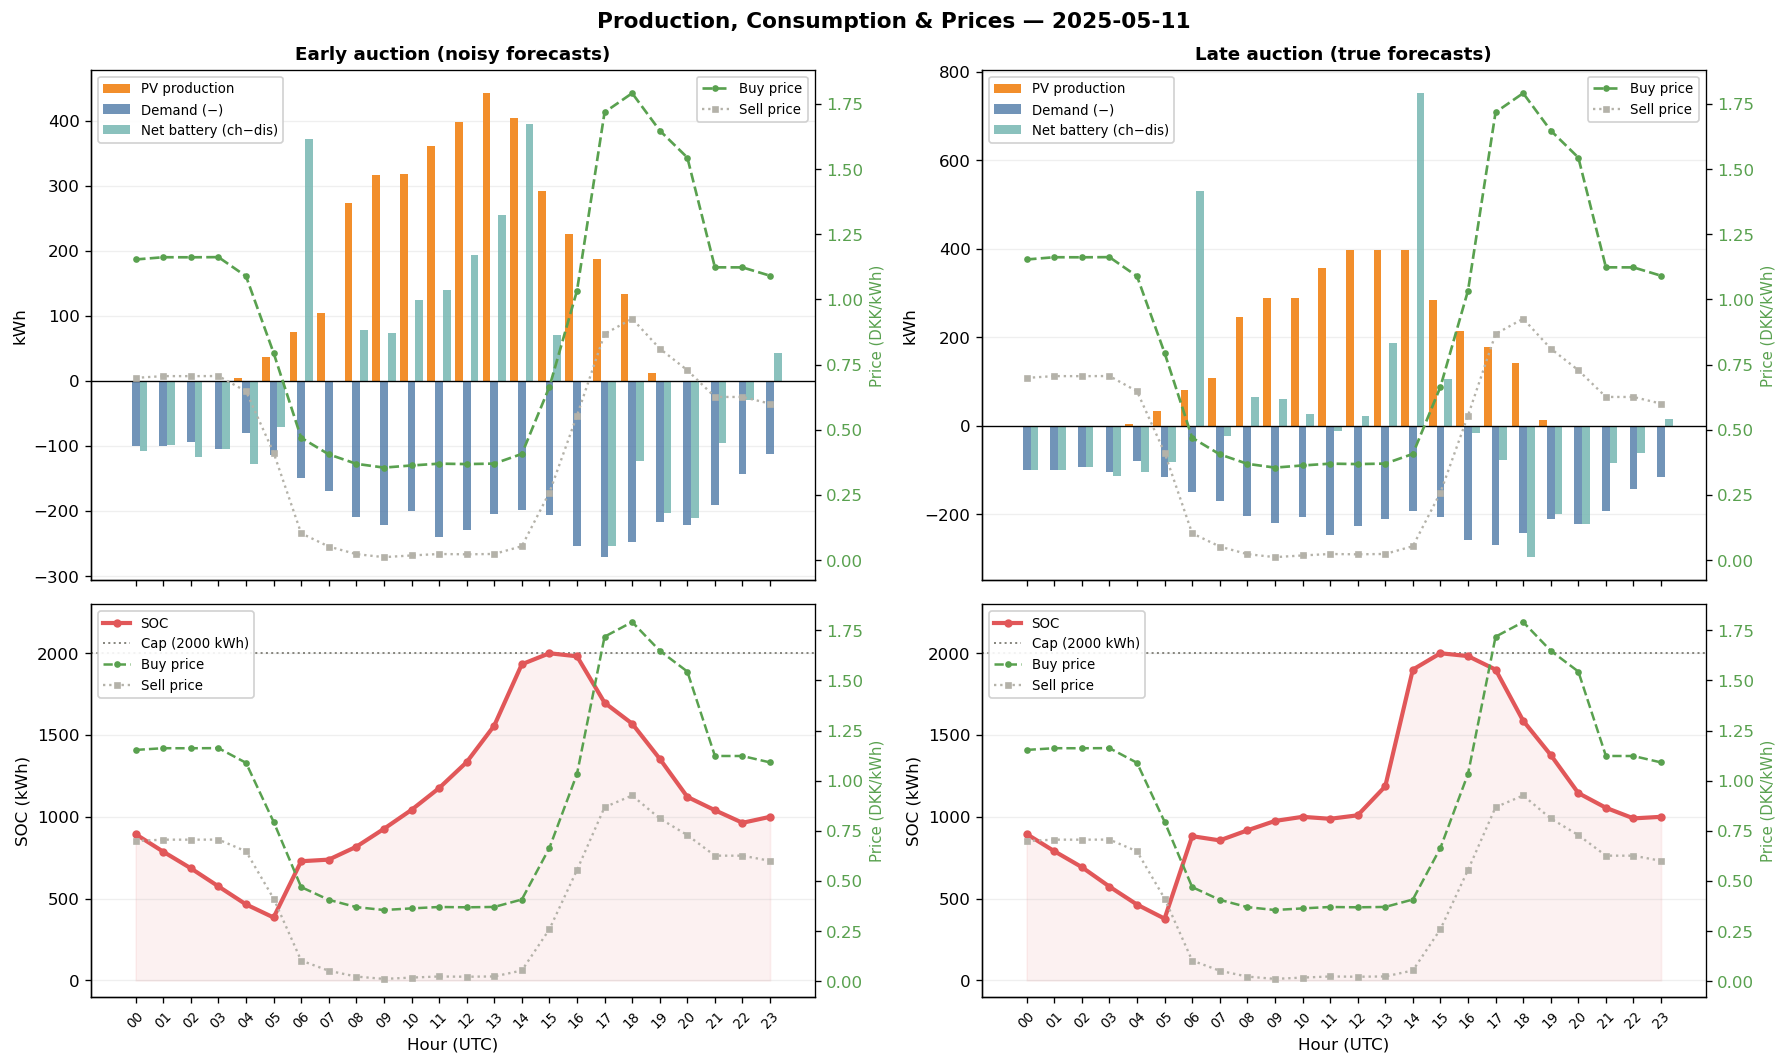

In [41]:
# ── Production, consumption & price overview — early vs late ─────────────────

def plot_prod_cons_prices(df_early, df_late, date):
    """
    2×2 panel: production/consumption bars for early and late dispatch,
    with buy/sell price overlaid on each panel.
    Top row: aggregated PV production, demand, and net battery flow per hour.
    Bottom row: SOC trace + buy/sell prices.
    """
    C_PV    = '#F28E2B'   # orange  — PV production
    C_LOAD  = '#4E79A7'   # blue    — consumption/demand
    C_BAT   = '#76B7B2'   # teal    — net battery (charge − discharge)
    C_SOC   = '#E15759'   # red     — state of charge
    C_BUY   = '#59A14F'   # green   — buy price
    C_SELL  = '#B4B2A9'   # grey    — sell price
    C_CAP   = '#888780'   # dimgrey — capacity line

    panels = [
        ('Early auction (noisy forecasts)', df_early),
        ('Late auction (true forecasts)',   df_late),
    ]

    fig, axes = plt.subplots(2, 2, figsize=(15, 9), sharex=True,
                             gridspec_kw={'height_ratios': [1.3, 1]})
    fig.suptitle(f'Production, Consumption & Prices — {date}',
                 fontsize=13, fontweight='bold')

    for col, (label, df_r) in enumerate(panels):
        sub = df_r.copy()
        if 'hour' not in sub.columns:
            sub['hour'] = np.arange(len(sub))
        sub = sub.sort_values('hour').reset_index(drop=True)
        h = sub['hour'].values
        w = 0.28

        net_bat = sub['b_ch_agg'].values - sub['b_dis_agg'].values   # +ve = net charging

        # ── Top panel: stacked production / consumption / battery ─────────
        ax_top = axes[0, col]
        ax_topr = ax_top.twinx()

        ax_top.bar(h - w,   sub['PV_agg'].values, width=w,
                   color=C_PV,   label='PV production',      zorder=3)
        ax_top.bar(h,      -sub['D_agg'].values,  width=w,
                   color=C_LOAD, alpha=0.8, label='Demand (−)',  zorder=3)
        ax_top.bar(h + w,   net_bat,               width=w,
                   color=C_BAT, alpha=0.85, label='Net battery (ch−dis)', zorder=3)

        ax_top.axhline(0, color='black', linewidth=0.8, zorder=4)
        ax_top.set_ylabel('kWh')
        ax_top.set_title(label, fontsize=11, fontweight='bold')
        ax_top.grid(axis='y', alpha=0.2)
        ax_top.spines[['top', 'right']].set_visible(False)
        ax_top.legend(fontsize=8, framealpha=0.9, loc='upper left')

        ax_topr.plot(h, sub['buy_price'].values,
                     color=C_BUY, linewidth=1.6, linestyle='--',
                     marker='o', markersize=3, label='Buy price', zorder=6)
        ax_topr.plot(h, sub['sell_price'].values,
                     color=C_SELL, linewidth=1.4, linestyle=':',
                     marker='s', markersize=3, label='Sell price', zorder=6)
        ax_topr.set_ylabel('Price (DKK/kWh)', fontsize=9, color=C_BUY)
        ax_topr.tick_params(axis='y', labelcolor=C_BUY)
        ax_topr.legend(fontsize=8, framealpha=0.9, loc='upper right')

        # ── Bottom panel: SOC + buy/sell price ───────────────────────────
        ax_bot  = axes[1, col]
        ax_botr = ax_bot.twinx()

        soc = sub['soc_agg'].values
        ax_bot.plot(h, soc, color=C_SOC, linewidth=2.5,
                    marker='o', markersize=4, zorder=5, label='SOC')
        ax_bot.fill_between(h, soc, alpha=0.08, color=C_SOC)
        ax_bot.axhline(S_AGG, color=C_CAP, linewidth=1.2, linestyle=':',
                       label=f'Capacity ({S_AGG:.0f} kWh)', zorder=4)

        ax_botr.plot(h, sub['buy_price'].values,
                     color=C_BUY,  linewidth=1.5, linestyle='--',
                     marker='o', markersize=3, label='Buy price',  zorder=6)
        ax_botr.plot(h, sub['sell_price'].values,
                     color=C_SELL, linewidth=1.4, linestyle=':',
                     marker='s', markersize=3, label='Sell price', zorder=6)
        ax_botr.set_ylabel('Price (DKK/kWh)', fontsize=9, color=C_BUY)
        ax_botr.tick_params(axis='y', labelcolor=C_BUY)

        ax_bot.set_ylabel('SOC (kWh)')
        ax_bot.set_ylim(bottom=-S_AGG * 0.05, top=S_AGG * 1.15)
        ax_bot.grid(axis='y', alpha=0.2)
        ax_bot.spines[['top', 'right']].set_visible(False)

        handles_bot = [
            Line2D([0], [0], color=C_SOC,  linewidth=2.5, marker='o', markersize=4, label='SOC'),
            Line2D([0], [0], color=C_CAP,  linewidth=1.2, linestyle=':', label=f'Cap ({S_AGG:.0f} kWh)'),
            Line2D([0], [0], color=C_BUY,  linewidth=1.5, linestyle='--', marker='o', markersize=3, label='Buy price'),
            Line2D([0], [0], color=C_SELL, linewidth=1.4, linestyle=':',  marker='s', markersize=3, label='Sell price'),
        ]
        ax_bot.legend(handles=handles_bot, fontsize=8, framealpha=0.9, loc='upper left')

    for ax in axes[1]:
        ax.set_xticks(range(24))
        ax.set_xticklabels([f'{hh:02d}' for hh in range(24)], rotation=45, fontsize=8)
        ax.set_xlabel('Hour (UTC)')

    plt.tight_layout()
    plt.show()


plot_prod_cons_prices(df_early_t, df_late_t, str(test_date))

## 9 — Single-day dispatch visualisation

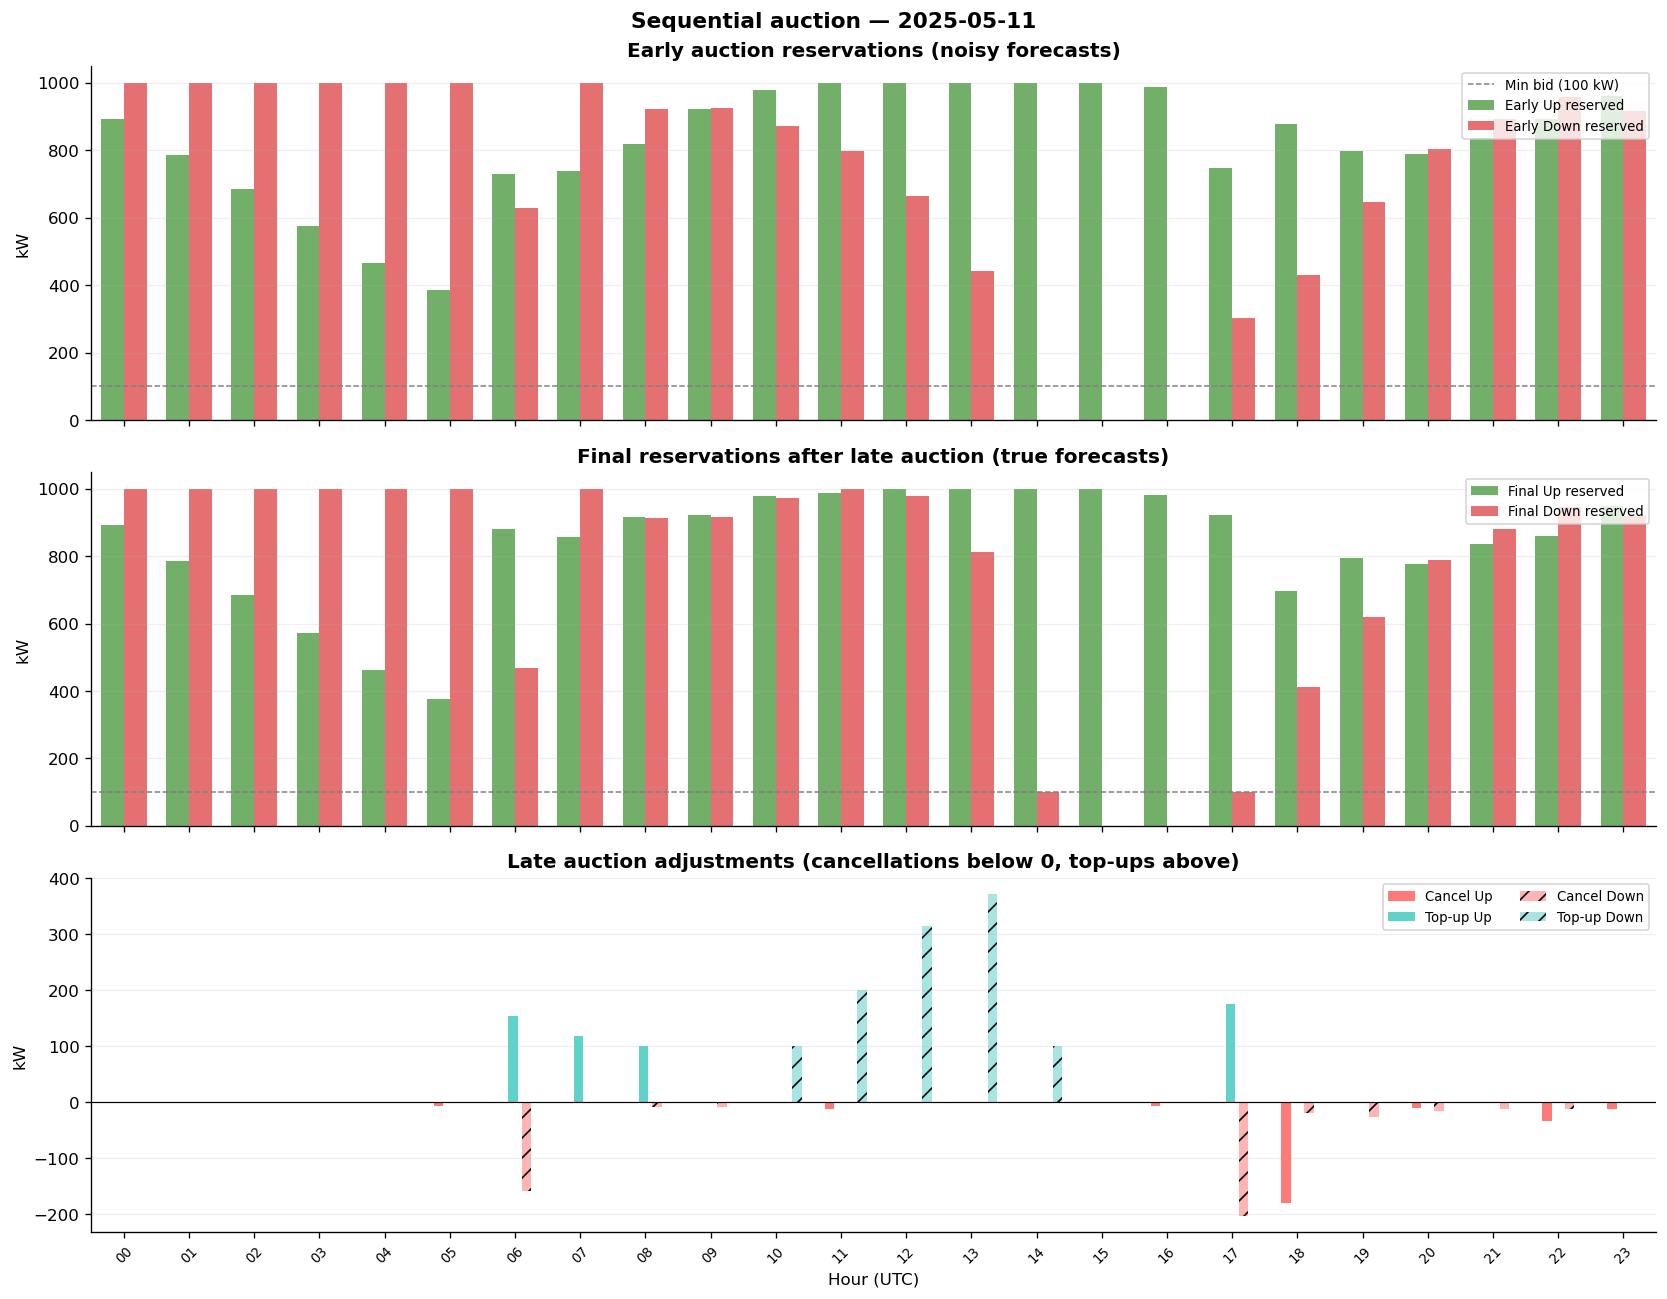

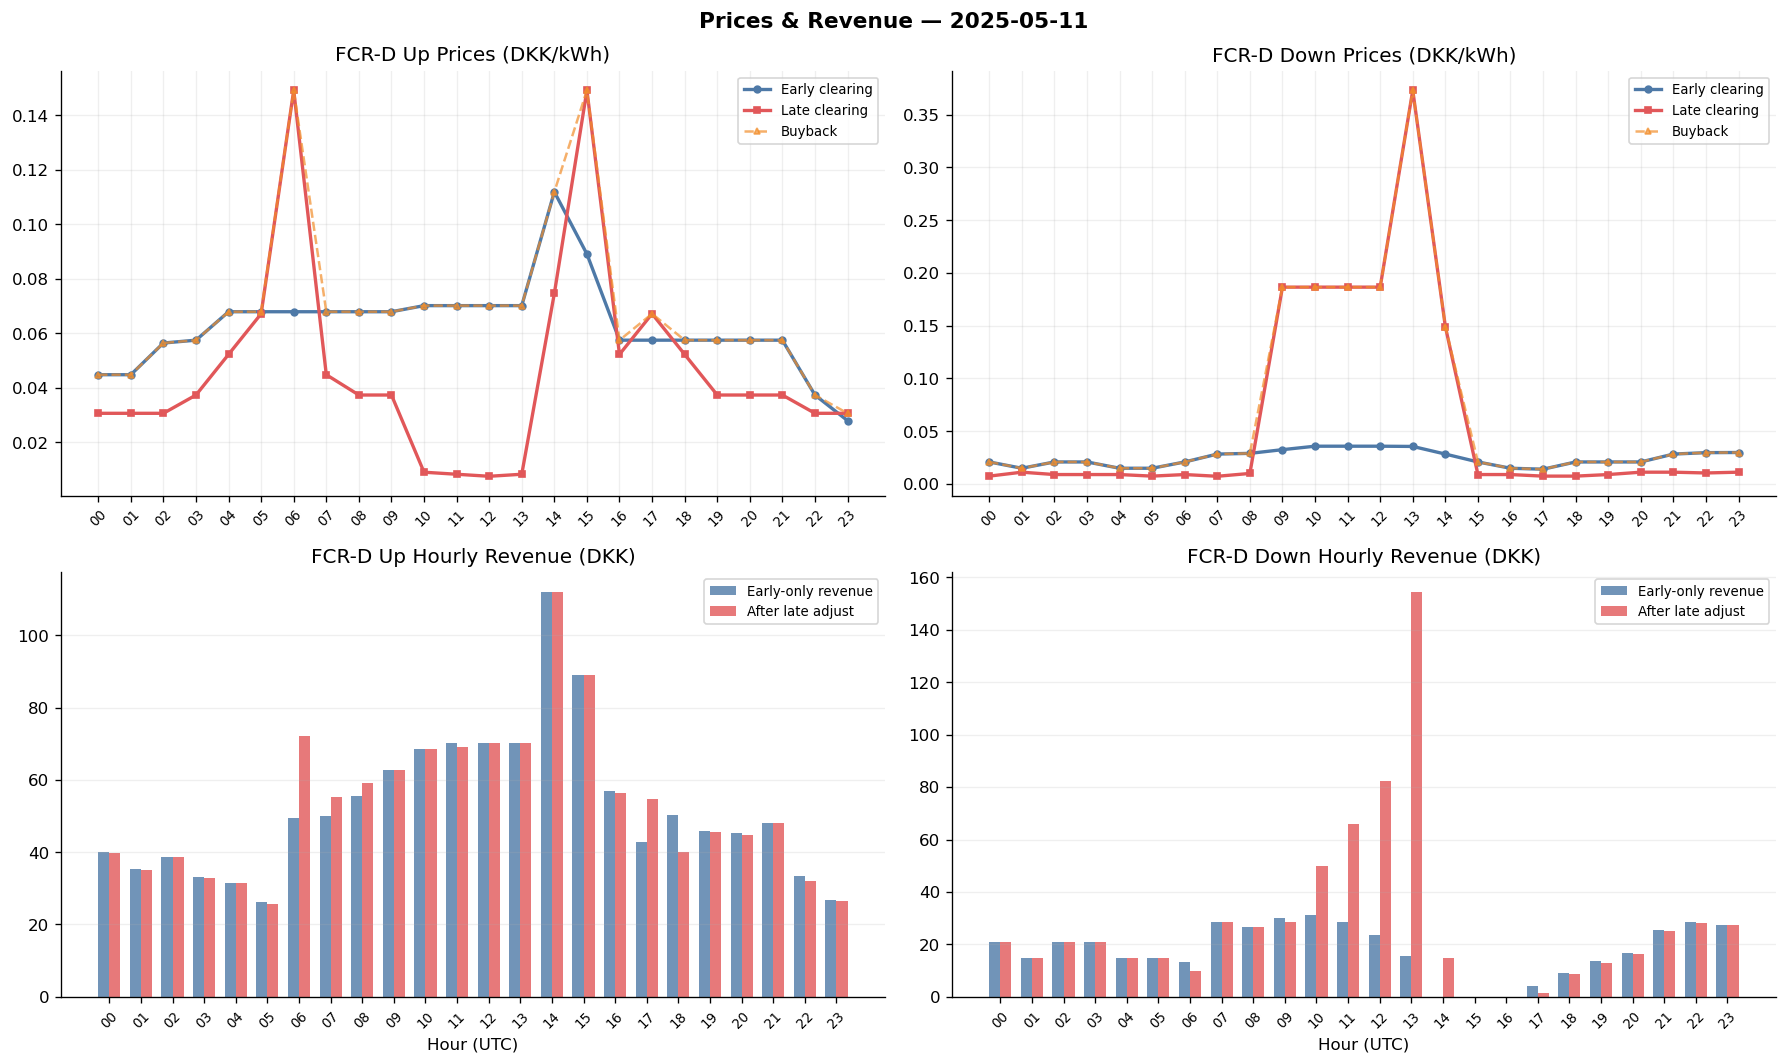

In [42]:
def plot_early_vs_late(df_early, df_late, date):
    #Three-panel: early reservations / final reservations / adjustments.
    C_UP   = '#59A14F'
    C_DN   = '#E15759'
    C_CANC = '#FF6B6B'
    C_TOP  = '#4ECDC4'

    fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)
    fig.suptitle(f'Sequential auction — {date}', fontsize=13, fontweight='bold')
    h = np.arange(24); w = 0.35

    ax = axes[0]
    ax.bar(h-w/2, df_early['p_res_up_agg'], w, color=C_UP, alpha=0.85, label='Early Up reserved')
    ax.bar(h+w/2, df_early['p_res_dn_agg'], w, color=C_DN, alpha=0.85, label='Early Down reserved')
    ax.axhline(P_MIN, color='gray', ls='--', lw=0.9, label=f'Min bid ({P_MIN:.0f} kW)')
    ax.set_ylabel('kW'); ax.set_title('Early auction reservations (noisy forecasts)', fontweight='bold')
    ax.legend(fontsize=8, loc='upper right'); ax.grid(axis='y', alpha=0.2)
    ax.spines[['top','right']].set_visible(False)

    ax = axes[1]
    ax.bar(h-w/2, df_late['p_res_up_final'], w, color=C_UP, alpha=0.85, label='Final Up reserved')
    ax.bar(h+w/2, df_late['p_res_dn_final'], w, color=C_DN, alpha=0.85, label='Final Down reserved')
    ax.axhline(P_MIN, color='gray', ls='--', lw=0.9)
    ax.set_ylabel('kW'); ax.set_title('Final reservations after late auction (true forecasts)', fontweight='bold')
    ax.legend(fontsize=8, loc='upper right'); ax.grid(axis='y', alpha=0.2)
    ax.spines[['top','right']].set_visible(False)

    ax = axes[2]
    w2 = w*0.42
    ax.bar(h-w/2,      -df_late['cancel_up'], w2, color=C_CANC, alpha=0.9, label='Cancel Up')
    ax.bar(h-w/2+w2,    df_late['topup_up'],  w2, color=C_TOP,  alpha=0.9, label='Top-up Up')
    ax.bar(h+w/2,      -df_late['cancel_dn'], w2, color=C_CANC, alpha=0.5, label='Cancel Down', hatch='//')
    ax.bar(h+w/2+w2,    df_late['topup_dn'],  w2, color=C_TOP,  alpha=0.5, label='Top-up Down', hatch='//')
    ax.axhline(0, color='black', lw=0.7)
    ax.set_ylabel('kW'); ax.set_xlabel('Hour (UTC)')
    ax.set_title('Late auction adjustments (cancellations below 0, top-ups above)', fontweight='bold')
    ax.legend(fontsize=8, loc='upper right', ncol=2); ax.grid(axis='y', alpha=0.2)
    ax.spines[['top','right']].set_visible(False)

    for ax in axes:
        ax.set_xticks(range(24))
        ax.set_xticklabels([f'{hh:02d}' for hh in range(24)], rotation=45, fontsize=8)
        ax.set_xlim(-0.5, 23.5)

    plt.tight_layout(); plt.show()


def plot_prices_revenue(df_early, df_late, date):
    #"""2×2: Up/Down prices across auctions + per-hour revenue comparison.""""
    C_E = '#4E79A7'; C_L = '#E15759'; C_BB = '#F28E2B'

    fig, axes = plt.subplots(2, 2, figsize=(15, 9))
    fig.suptitle(f'Prices & Revenue — {date}', fontsize=13, fontweight='bold')
    h = np.arange(24); w = 0.35

    for col, (lbl, ep, lp, bup) in enumerate([
        ('Up',   'fcrd_up_price', 'fcrd_up_price_late', 'buyback_up'),
        ('Down', 'fcrd_dn_price', 'fcrd_dn_price_late', 'buyback_dn'),
    ]):
        ax = axes[0, col]
        ax.plot(h, df_early[ep].values,   'o-', color=C_E,  lw=2, ms=4, label='Early clearing')
        ax.plot(h, df_late[lp].values,    's-', color=C_L,  lw=2, ms=4, label='Late clearing')
        ax.plot(h, df_late[bup].values,   '^--',color=C_BB, lw=1.5, ms=4, alpha=0.7, label='Buyback')
        ax.set_title(f'FCR-D {lbl} Prices (DKK/kWh)')
        ax.legend(fontsize=8); ax.grid(alpha=0.2)
        ax.spines[['top','right']].set_visible(False)

    for col, (lbl, rev_e, rev_t) in enumerate([
        ('Up',   'rev_up',        'rev_total_up'),
        ('Down', 'rev_dn',        'rev_total_dn'),
    ]):
        ax = axes[1, col]
        ax.bar(h-w/2, df_early[rev_e].values,  w, color=C_E, alpha=0.8, label='Early-only revenue')
        ax.bar(h+w/2, df_late[rev_t].values,   w, color=C_L, alpha=0.8, label='After late adjust')
        ax.set_title(f'FCR-D {lbl} Hourly Revenue (DKK)')
        ax.set_xlabel('Hour (UTC)')
        ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.2)
        ax.spines[['top','right']].set_visible(False)

    for ax in axes.flat:
        ax.set_xticks(range(24)); ax.set_xticklabels([f'{hh:02d}' for hh in range(24)], rotation=45, fontsize=8)

    plt.tight_layout(); plt.show()


plot_early_vs_late(df_early_t, df_late_t, str(test_date))
plot_prices_revenue(df_early_t, df_late_t, str(test_date))

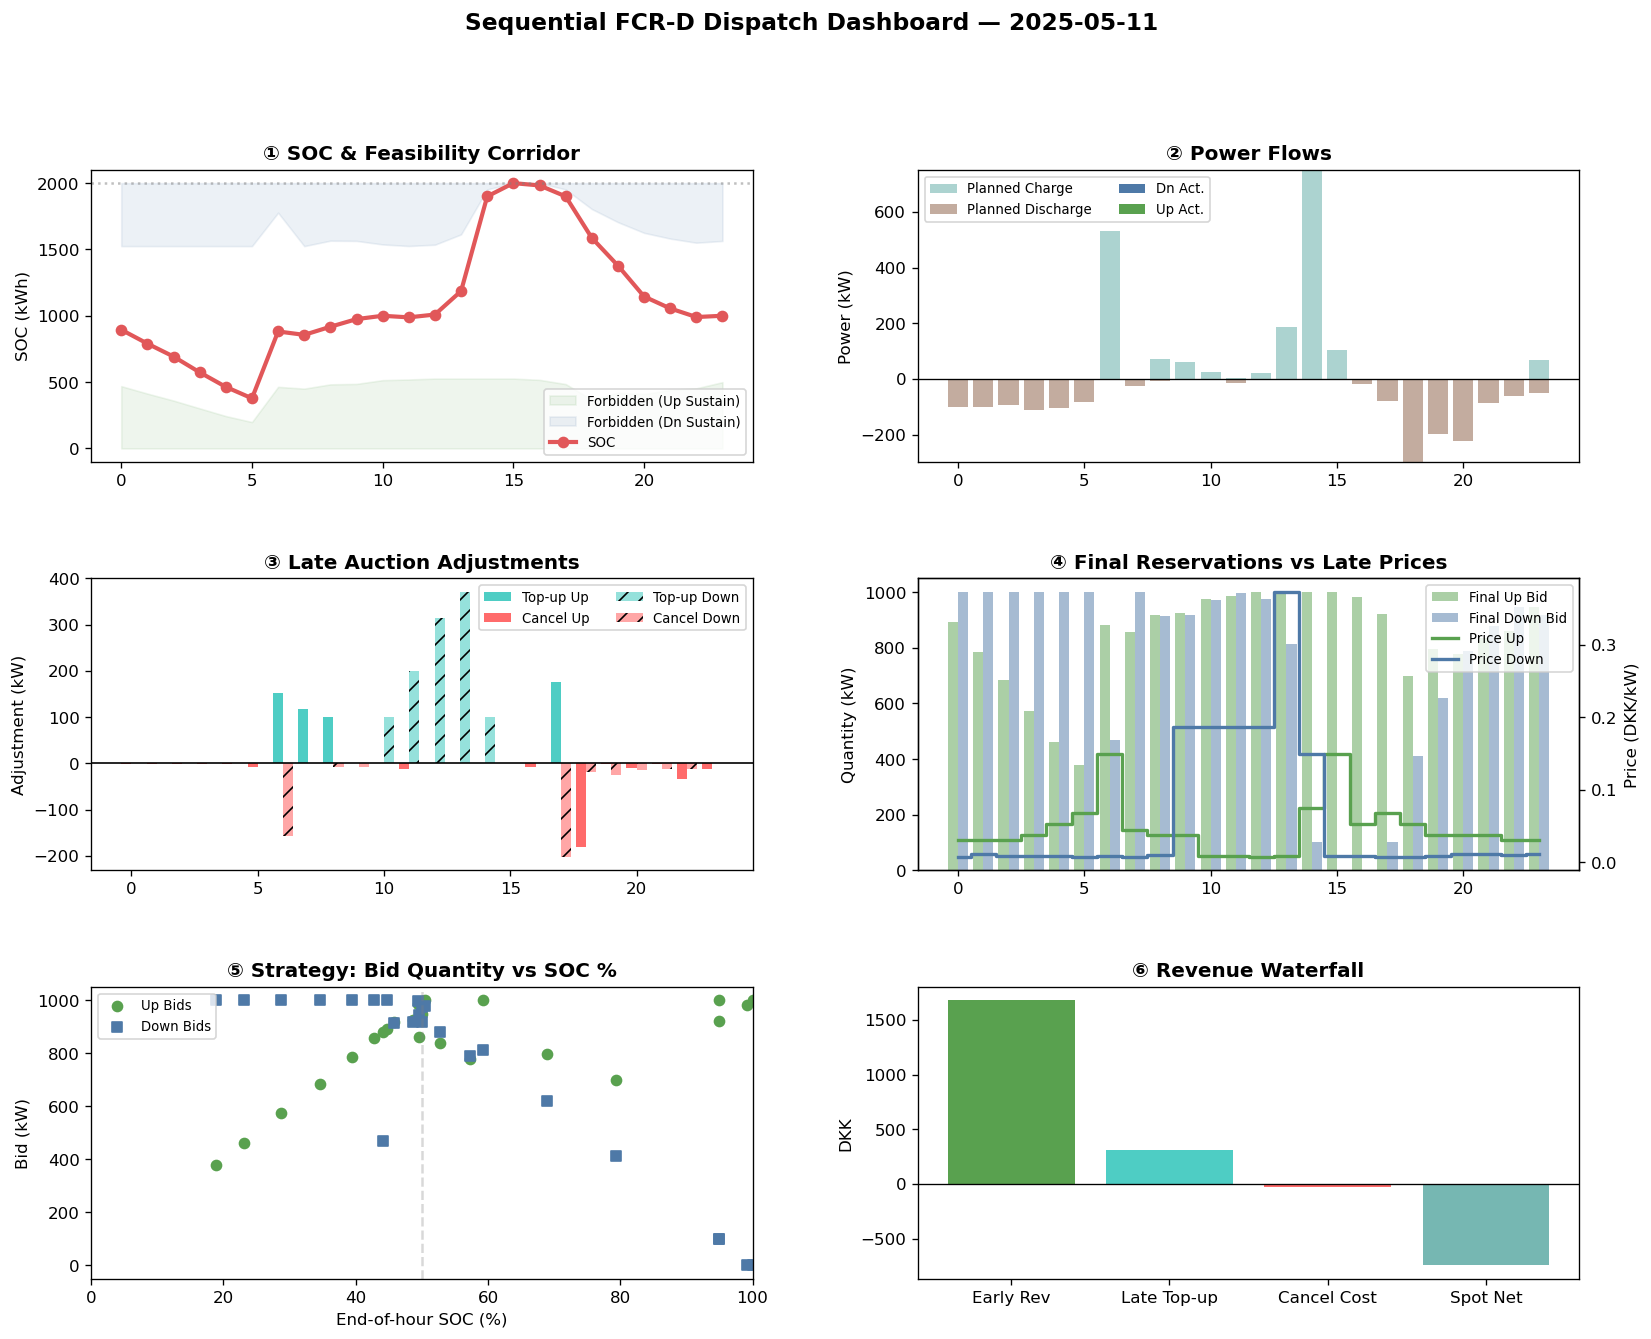

In [43]:
def plot_fcrd_dashboard_sequential(df_late, date):
    """
    Six-panel dashboard updated for Sequential Auctions.
    Falls back to the accepted-quantity columns produced by extract_late_day.
    """
    sub = df_late.copy()
    if 'hour' not in sub.columns:
        sub['hour'] = sub.index

    # --- Data Enrichment ---
    p_acc_up = sub['p_acc_up_early'] if 'p_acc_up_early' in sub.columns else sub.get('p_acc_up_agg')
    p_acc_dn = sub['p_acc_dn_early'] if 'p_acc_dn_early' in sub.columns else sub.get('p_acc_dn_agg')
    if p_acc_up is None or p_acc_dn is None:
        raise KeyError('Missing accepted-quantity columns: expected p_acc_up_early/p_acc_dn_early')

    # 1. Early Revenue (the locked-in part from Auction 1)
    if 'rev_early' not in sub.columns:
        sub['rev_early'] = (p_acc_up * sub['fcrd_up_price_early'] +
                            p_acc_dn * sub['fcrd_dn_price_early'])

    # 2. Spot Market Revenue (Revenue from selling - Cost of buying)
    if 'rev_spot' not in sub.columns:
        # Subtract activations because they are handled by FCR-D payments.
        sub['rev_spot'] = (sub['sell_price'] * (sub['p_ex_agg'] - sub['p_act_up_agg']) -
                           sub['buy_price'] * (sub['p_im_agg'] - sub['p_act_dn_agg']))

    # ─── Colours ────────────────────────────────────────────────────────────
    C_SOC   = '#E15759'; C_UP    = '#59A14F'; C_DN    = '#4E79A7'
    C_CH    = '#76B7B2'; C_DIS   = '#9C755F'; C_CANC  = '#FF6B6B'
    C_TOP   = '#4ECDC4'; C_CAP   = '#B4B2A9'

    fig = plt.figure(figsize=(16, 12))
    gs = fig.add_gridspec(3, 2, hspace=0.4, wspace=0.25)
    fig.suptitle(f'Sequential FCR-D Dispatch Dashboard — {date}', 
                 fontsize=14, fontweight='bold', y=0.99)
    h = sub['hour'].values

    # --- Panel 1: SOC & FCR-D Corridor ---
    ax = fig.add_subplot(gs[0, 0])
    soc_floor_up = (T_SUSTAIN / ETA_MEAN) * sub['p_res_up_final'].values
    soc_ceil_dn  = S_AGG - (T_SUSTAIN * ETA_MEAN) * sub['p_res_dn_final'].values
    ax.fill_between(h, 0, soc_floor_up, color=C_UP, alpha=0.1, label='Forbidden (Up Sustain)')
    ax.fill_between(h, soc_ceil_dn, S_AGG, color=C_DN, alpha=0.1, label='Forbidden (Dn Sustain)')
    ax.plot(h, sub['soc_agg'].values, color=C_SOC, lw=2.5, marker='o', label='SOC')
    ax.axhline(S_AGG, color='gray', ls=':', alpha=0.5)
    ax.set_title('① SOC & Feasibility Corridor', fontweight='bold')
    ax.set_ylabel('SOC (kWh)'); ax.legend(fontsize=8, loc='lower right')

    # --- Panel 2: Power Flows ---
    ax = fig.add_subplot(gs[0, 1])
    ax.bar(h, sub['b_ch_agg'], color=C_CH, alpha=0.6, label='Planned Charge')
    ax.bar(h, -sub['b_dis_agg'], color=C_DIS, alpha=0.6, label='Planned Discharge')
    ax.bar(h, sub['p_act_dn_agg'], bottom=sub['b_ch_agg'], color=C_DN, label='Dn Act.')
    ax.bar(h, -sub['p_act_up_agg'], bottom=-sub['b_dis_agg'], color=C_UP, label='Up Act.')
    ax.axhline(0, color='black', lw=0.8); ax.set_title('② Power Flows', fontweight='bold')
    ax.set_ylabel('Power (kW)'); ax.legend(fontsize=8, ncol=2)

    # --- Panel 3: Adjustments ---
    ax = fig.add_subplot(gs[1, 0])
    w = 0.4
    ax.bar(h - w/2, sub['topup_up'], w, color=C_TOP, label='Top-up Up')
    ax.bar(h - w/2, -sub['cancel_up'], w, color=C_CANC, label='Cancel Up')
    ax.bar(h + w/2, sub['topup_dn'], w, color=C_TOP, alpha=0.6, label='Top-up Down', hatch='//')
    ax.bar(h + w/2, -sub['cancel_dn'], w, color=C_CANC, alpha=0.6, label='Cancel Down', hatch='//')
    ax.axhline(0, color='black', lw=1); ax.set_title('③ Late Auction Adjustments', fontweight='bold')
    ax.set_ylabel('Adjustment (kW)'); ax.legend(fontsize=8, ncol=2)

    # --- Panel 4: Final Bids vs Market Prices ---
    ax = fig.add_subplot(gs[1, 1])
    axr = ax.twinx()
    ax.bar(h-0.2, sub['p_res_up_final'], 0.4, color=C_UP, alpha=0.5, label='Final Up Bid')
    ax.bar(h+0.2, sub['p_res_dn_final'], 0.4, color=C_DN, alpha=0.5, label='Final Down Bid')
    axr.step(h, sub['fcrd_up_price_late'], where='mid', color=C_UP, lw=2, label='Price Up')
    axr.step(h, sub['fcrd_dn_price_late'], where='mid', color=C_DN, lw=2, label='Price Down')
    ax.set_title('④ Final Reservations vs Late Prices', fontweight='bold')
    ax.set_ylabel('Quantity (kW)'); axr.set_ylabel('Price (DKK/kW)')
    lines, labels = ax.get_legend_handles_labels(); lines2, labels2 = axr.get_legend_handles_labels()
    ax.legend(lines + lines2, labels + labels2, loc='upper right', fontsize=8)

    # --- Panel 5: Bidding Strategy ---
    ax = fig.add_subplot(gs[2, 0])
    ax.scatter(sub['soc_agg']/S_AGG*100, sub['p_res_up_final'], color=C_UP, label='Up Bids')
    ax.scatter(sub['soc_agg']/S_AGG*100, sub['p_res_dn_final'], color=C_DN, label='Down Bids', marker='s')
    ax.axvline(50, color='gray', ls='--', alpha=0.3); ax.set_xlim(0, 100)
    ax.set_title('⑤ Strategy: Bid Quantity vs SOC %', fontweight='bold')
    ax.set_xlabel('End-of-hour SOC (%)'); ax.set_ylabel('Bid (kW)'); ax.legend(fontsize=8)

    # --- Panel 6: Revenue Waterfall ---
    ax = fig.add_subplot(gs[2, 1])
    rev_components = {
        'Early Rev': sub['rev_early'].sum(),
        'Late Top-up': (sub['topup_up']*sub['fcrd_up_price_late'] + sub['topup_dn']*sub['fcrd_dn_price_late']).sum(),
        'Cancel Cost': -(sub['cancel_up']*sub['buyback_up'] + sub['cancel_dn']*sub['buyback_dn']).sum(),
        'Spot Net': sub['rev_spot'].sum()
    }

    names = list(rev_components.keys()); values = list(rev_components.values())
    ax.bar(names, values, color=[C_UP, C_TOP, C_CANC, C_CH])
    ax.axhline(0, color='black', lw=0.8); ax.set_title('⑥ Revenue Waterfall', fontweight='bold')
    ax.set_ylabel('DKK')

    plt.tight_layout(); plt.show()

plot_fcrd_dashboard_sequential(df_late_t, str(test_date))

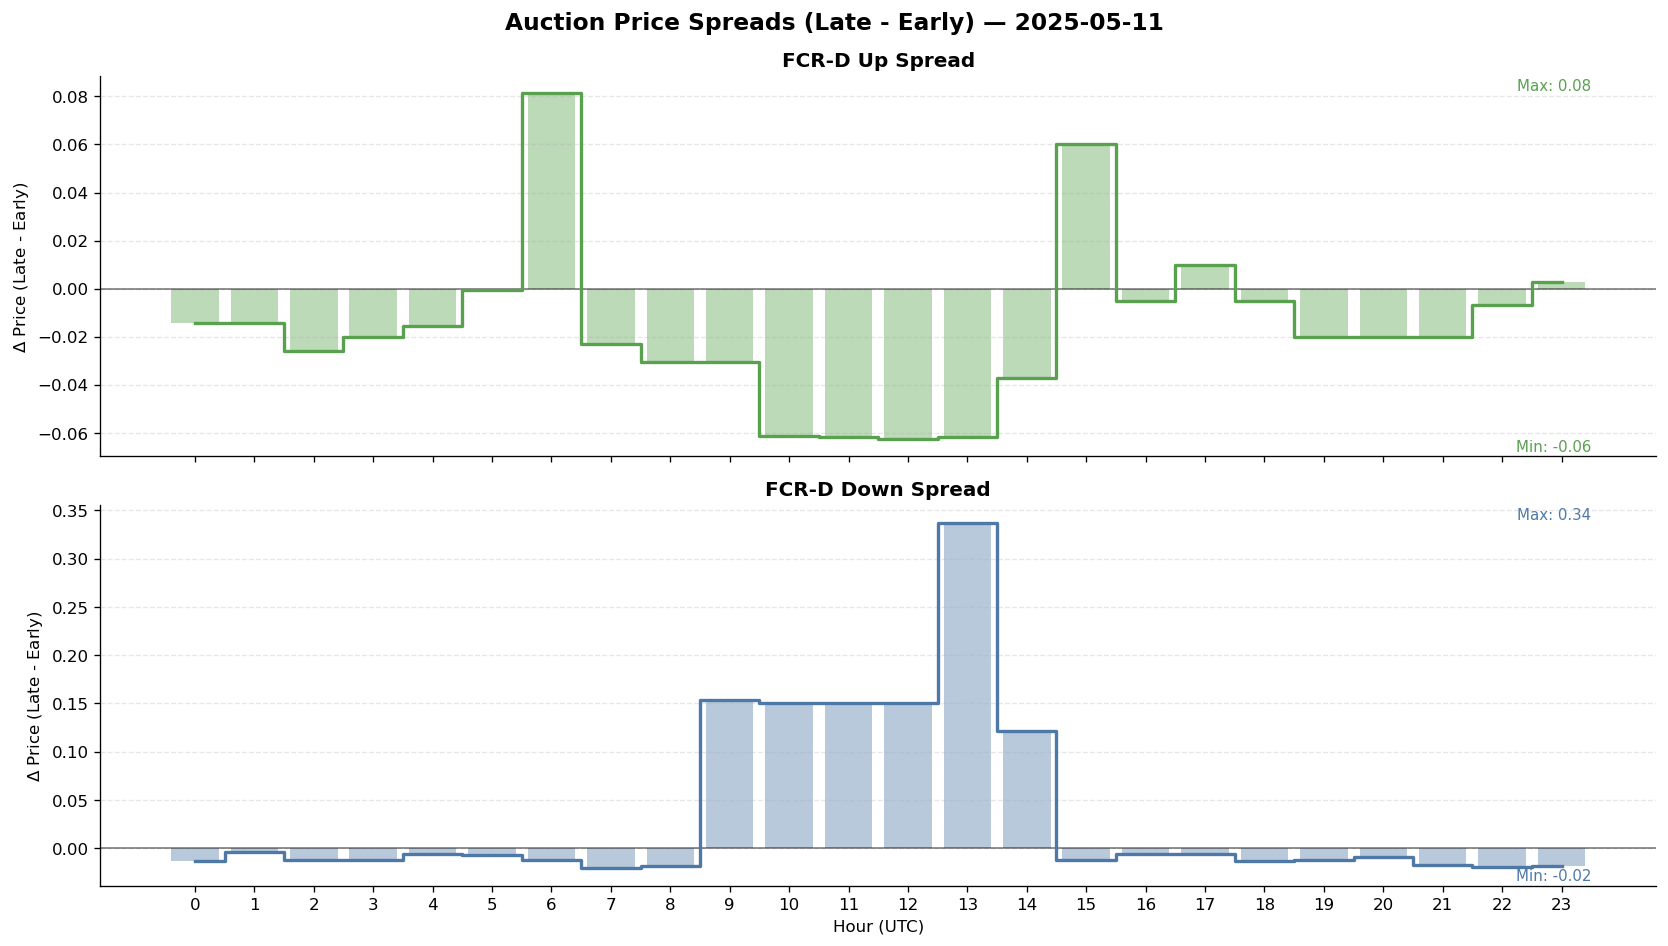

In [44]:
def plot_auction_price_spreads(df_late, date):
    """
    Visualizes the delta between Early and Late clearing prices.
    Positive delta = Late is more expensive (incentive to top-up).
    Negative delta = Early was more expensive (incentive to avoid cancellation).
    """
    sub = df_late.copy()
    h = sub.index

    # Fall back to the old names only if a cached dataframe still uses them.
    early_up = sub['fcrd_up_price_early'] if 'fcrd_up_price_early' in sub.columns else sub['fcrd_up_price']
    early_dn = sub['fcrd_dn_price_early'] if 'fcrd_dn_price_early' in sub.columns else sub['fcrd_dn_price']

    # Calculate deltas
    sub['delta_up'] = sub['fcrd_up_price_late'] - early_up
    sub['delta_dn'] = sub['fcrd_dn_price_late'] - early_dn

    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    fig.suptitle(f'Auction Price Spreads (Late - Early) — {date}', fontsize=14, fontweight='bold')

    colors = ['#59A14F', '#4E79A7']  # Green for Up, Blue for Dn
    labels = ['FCR-D Up Spread', 'FCR-D Down Spread']
    deltas = ['delta_up', 'delta_dn']

    for i, ax in enumerate(axes):
        ax.axhline(0, color='black', lw=1, alpha=0.5)
        ax.bar(h, sub[deltas[i]], color=colors[i], alpha=0.4, label=f'{labels[i]} (DKK/kW)')
        ax.step(h, sub[deltas[i]], where='mid', color=colors[i], lw=2)
        ax.set_title(labels[i], fontweight='bold')
        ax.set_ylabel('$\\Delta$ Price (Late - Early)')
        ax.grid(axis='y', alpha=0.3, ls='--')
        ax.spines[['top', 'right']].set_visible(False)

        max_val = sub[deltas[i]].max()
        min_val = sub[deltas[i]].min()
        ax.text(23.5, max_val, f'Max: {max_val:.2f}', ha='right', va='bottom', color=colors[i], fontsize=9)
        ax.text(23.5, min_val, f'Min: {min_val:.2f}', ha='right', va='top', color=colors[i], fontsize=9)

    axes[1].set_xlabel('Hour (UTC)')
    plt.xticks(range(24))
    plt.tight_layout()
    plt.show()

# Run the plot
plot_auction_price_spreads(df_late_t, str(test_date))

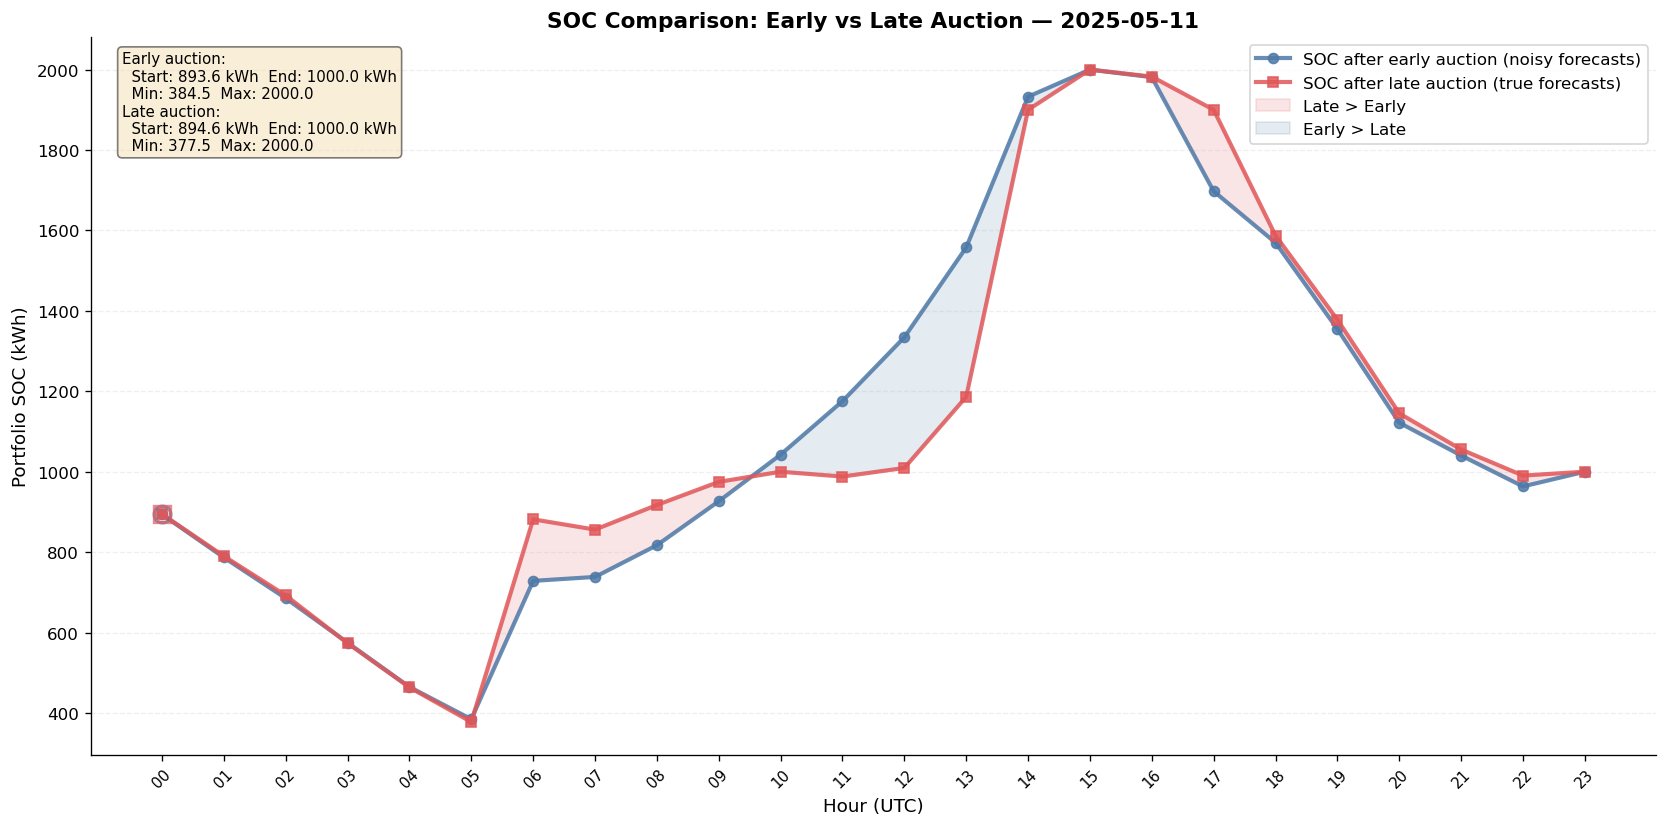

In [45]:
def plot_soc_comparison(df_early, df_late, date):
    """
    Compare SOC trajectories from early auction vs. late auction.
    Shows how the late auction adjustments (cancellations/top-ups) affect the final SOC path.
    """
    C_EARLY = '#4E79A7'
    C_LATE = '#E15759'
    C_FILL_EARLY = '#4E79A7'
    C_FILL_LATE = '#E15759'
    
    fig, ax = plt.subplots(figsize=(14, 7))
    h = np.arange(24)
    
    # Plot SOC curves
    ax.plot(h, df_early['soc_agg'].values, 'o-', color=C_EARLY, lw=2.5, markersize=6, 
            label='SOC after early auction (noisy forecasts)', alpha=0.85)
    ax.plot(h, df_late['soc_agg'].values, 's-', color=C_LATE, lw=2.5, markersize=6,
            label='SOC after late auction (true forecasts)', alpha=0.85)
    
    # Add fill between to show the difference
    ax.fill_between(h, df_early['soc_agg'].values, df_late['soc_agg'].values,
                    where=(df_late['soc_agg'] >= df_early['soc_agg']),
                    color=C_LATE, alpha=0.15, interpolate=True, label='Late > Early')
    ax.fill_between(h, df_early['soc_agg'].values, df_late['soc_agg'].values,
                    where=(df_late['soc_agg'] < df_early['soc_agg']),
                    color=C_EARLY, alpha=0.15, interpolate=True, label='Early > Late')
    
    # Mark start and end
    ax.plot(0, df_early['soc_agg'].iloc[0], 'o', color=C_EARLY, markersize=10, markeredgewidth=2, 
            markerfacecolor='none', alpha=0.7)
    ax.plot(0, df_late['soc_agg'].iloc[0], 's', color=C_LATE, markersize=10, markeredgewidth=2,
            markerfacecolor='none', alpha=0.7)
    
    # Add grid and labels
    ax.grid(axis='y', alpha=0.2, linestyle='--')
    ax.set_xlabel('Hour (UTC)', fontsize=11)
    ax.set_ylabel('Portfolio SOC (kWh)', fontsize=11)
    ax.set_title(f'SOC Comparison: Early vs Late Auction — {date}', fontsize=13, fontweight='bold')
    ax.set_xticks(range(24))
    ax.set_xticklabels([f'{hh:02d}' for hh in range(24)], rotation=45, fontsize=9)
    ax.legend(fontsize=10, loc='best')
    ax.spines[['top', 'right']].set_visible(False)
    
    # Add summary stats
    soc_init_early = df_early['soc_agg'].iloc[0]
    soc_final_early = df_early['soc_agg'].iloc[-1]
    soc_init_late = df_late['soc_agg'].iloc[0]
    soc_final_late = df_late['soc_agg'].iloc[-1]
    
    textstr = (f'Early auction:\n'
               f'  Start: {soc_init_early:.1f} kWh  End: {soc_final_early:.1f} kWh\n'
               f'  Min: {df_early["soc_agg"].min():.1f}  Max: {df_early["soc_agg"].max():.1f}\n'
               f'Late auction:\n'
               f'  Start: {soc_init_late:.1f} kWh  End: {soc_final_late:.1f} kWh\n'
               f'  Min: {df_late["soc_agg"].min():.1f}  Max: {df_late["soc_agg"].max():.1f}')
    ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=9,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.show()

plot_soc_comparison(df_early_t, df_late_t, str(test_date))

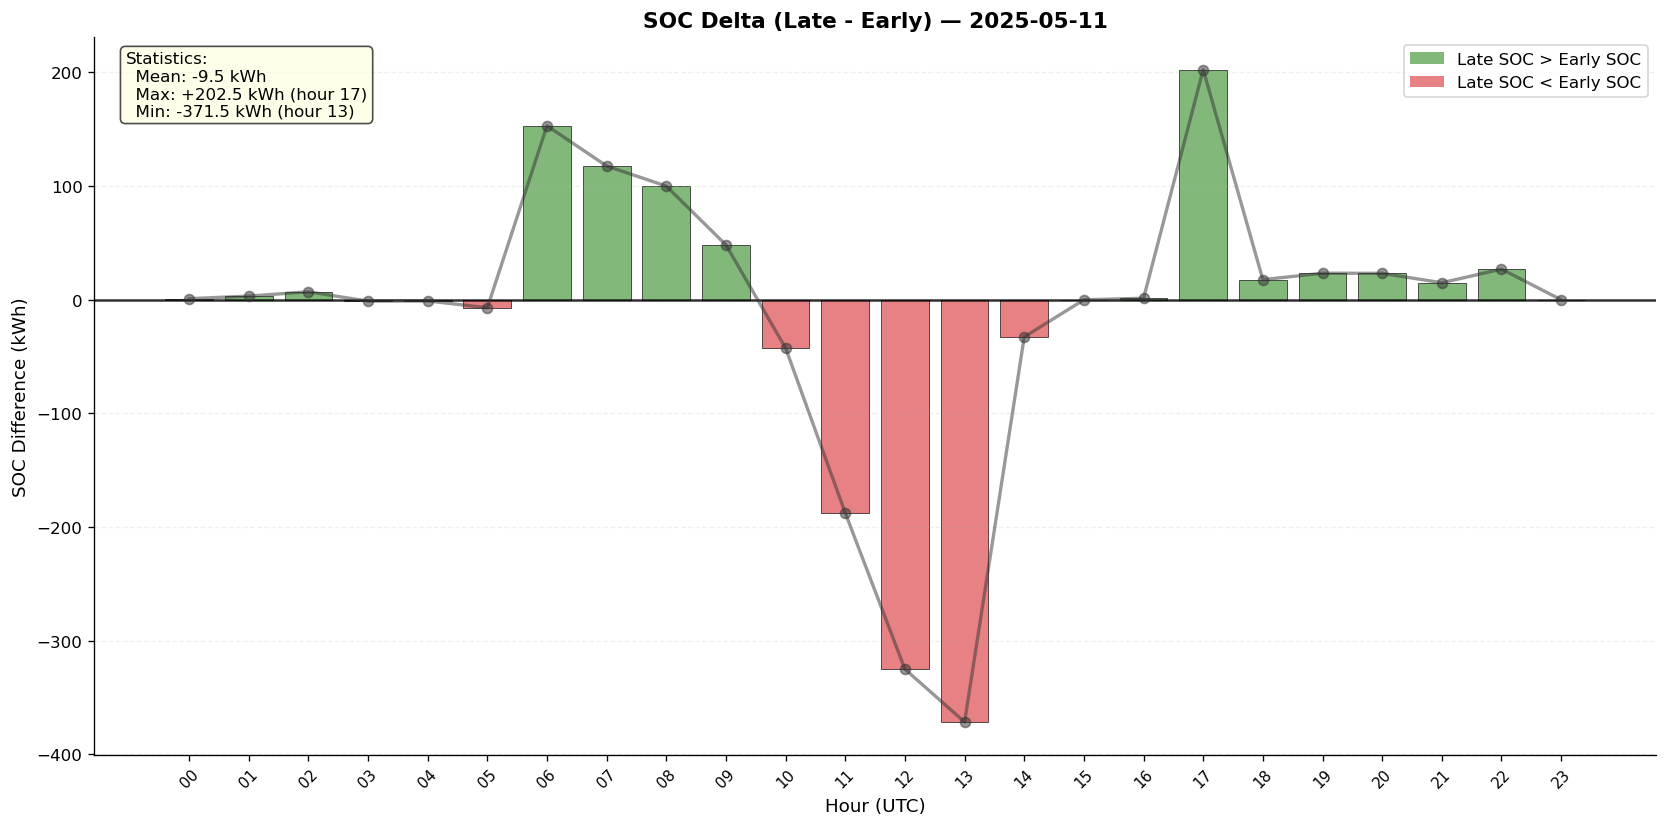

In [46]:
def plot_soc_delta(df_early, df_late, date):
    """
    Plot the SOC difference: Late - Early.
    Positive delta = Late auction results in higher SOC (more conservative discharge/more charge).
    Negative delta = Late auction results in lower SOC (more aggressive discharge).
    """
    C_POS = '#59A14F'  # Green for positive
    C_NEG = '#E15759'  # Red for negative
    
    fig, ax = plt.subplots(figsize=(14, 7))
    h = np.arange(24)
    
    # Calculate delta
    delta_soc = df_late['soc_agg'].values - df_early['soc_agg'].values
    
    # Plot as bar chart with color based on sign
    colors = [C_POS if x >= 0 else C_NEG for x in delta_soc]
    ax.bar(h, delta_soc, color=colors, alpha=0.75, edgecolor='black', linewidth=0.5)
    
    # Add zero line
    ax.axhline(0, color='black', lw=1.5, linestyle='-', alpha=0.8)
    
    # Add a smooth curve overlay
    ax.plot(h, delta_soc, 'o-', color='#333333', lw=2, markersize=6, alpha=0.5, label='Delta trend')
    
    # Grid and labels
    ax.grid(axis='y', alpha=0.2, linestyle='--')
    ax.set_xlabel('Hour (UTC)', fontsize=11)
    ax.set_ylabel('SOC Difference (kWh)', fontsize=11)
    ax.set_title(f'SOC Delta (Late - Early) — {date}', fontsize=13, fontweight='bold')
    ax.set_xticks(range(24))
    ax.set_xticklabels([f'{hh:02d}' for hh in range(24)], rotation=45, fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)
    
    # Add stats
    mean_delta = delta_soc.mean()
    max_delta = delta_soc.max()
    min_delta = delta_soc.min()
    
    textstr = (f'Statistics:\n'
               f'  Mean: {mean_delta:+.1f} kWh\n'
               f'  Max: {max_delta:+.1f} kWh (hour {np.argmax(delta_soc):02d})\n'
               f'  Min: {min_delta:+.1f} kWh (hour {np.argmin(delta_soc):02d})')
    ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7))
    
    # Legend
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=C_POS, alpha=0.75, label='Late SOC > Early SOC'),
                       Patch(facecolor=C_NEG, alpha=0.75, label='Late SOC < Early SOC')]
    ax.legend(handles=legend_elements, fontsize=10, loc='upper right')
    
    plt.tight_layout()
    plt.show()

plot_soc_delta(df_early_t, df_late_t, str(test_date))

In [47]:
# here plot the SOC for the battery after early auction and compare to after late auction, give me one diagram with the two SOC curves

## 10 — Yearly run

For each day: base (no FCR-D) → early MILP → extract accepted → late MILP.
Results checkpointed every 30 days. Set `FORCE_RERUN = True` to re-solve.

In [48]:
FORCE_RERUN       = False
CHECKPOINT_EVERY  = 30

DATA_DIR.mkdir(parents=True, exist_ok=True)

if (not FORCE_RERUN) and OUT_BASE.exists() and OUT_EARLY.exists() and OUT_LATE.exists():
    print('✓ Cached CSVs found — skip to next cell to load, or set FORCE_RERUN=True.')
else:
    dates = sorted(set(df_b.index.date))
    res_base, res_early, res_late, failed = [], [], [], []

    for i, date in enumerate(tqdm(dates, desc='Sequential FCR-D')):
        result = get_day_per_ec(date)
        if result is None:
            failed.append(('no_data', str(date))); continue
        de, dl = result

        # ── Base ────────────────────────────────────────────────────────
        try:
            m = build_early(de, fcrd=False); r = solve_model(m)
            if str(r.solver.termination_condition) == 'optimal':
                res_base.append(extract_early_day(m, de, has_fcrd=False))
            else:
                failed.append(('base', str(date)))
        except Exception as ex:
            failed.append(('base_ex', str(date), str(ex)[:80]))

        # ── Early ────────────────────────────────────────────────────────
        try:
            me = build_early(de, fcrd=True); r = solve_model(me)
            if str(r.solver.termination_condition) != 'optimal':
                failed.append(('early', str(date))); continue
            res_early.append(extract_early_day(me, de, has_fcrd=True))
        except Exception as ex:
            failed.append(('early_ex', str(date), str(ex)[:80])); continue

        # ── Late ─────────────────────────────────────────────────────────
        try:
            acc_up, acc_dn = extract_early_accepted(me)
            ml = build_late(dl, acc_up, acc_dn, de['fcrd_up_price'], de['fcrd_dn_price'])
            r = solve_model(ml)
            if str(r.solver.termination_condition) == 'optimal':
                res_late.append(extract_late_day(ml, dl, de['fcrd_up_price'], de['fcrd_dn_price']))
            else:
                failed.append(('late', str(date)))
        except Exception as ex:
            failed.append(('late_ex', str(date), str(ex)[:80]))

        if (i+1) % CHECKPOINT_EVERY == 0:
            if res_base:  pd.concat(res_base,  ignore_index=True).to_csv(OUT_BASE,  index=False)
            if res_early: pd.concat(res_early, ignore_index=True).to_csv(OUT_EARLY, index=False)
            if res_late:  pd.concat(res_late,  ignore_index=True).to_csv(OUT_LATE,  index=False)

    portfolio_base  = pd.concat(res_base,  ignore_index=True)
    portfolio_early = pd.concat(res_early, ignore_index=True)
    portfolio_late  = pd.concat(res_late,  ignore_index=True)
    portfolio_base .to_csv(OUT_BASE,  index=False)
    portfolio_early.to_csv(OUT_EARLY, index=False)
    portfolio_late .to_csv(OUT_LATE,  index=False)

    import json as _j
    with open(DATA_DIR/'results_nb06_failed.json','w') as f:
        _j.dump(failed, f, indent=2)
    print(f'Done: base={len(res_base)}  early={len(res_early)}  late={len(res_late)}  failed={len(failed)}')

Sequential FCR-D: 100%|██████████| 365/365 [39:44<00:00,  6.53s/it]


Done: base=355  early=355  late=355  failed=10


## 10b — Load cached results

In [49]:
portfolio_base  = pd.read_csv(OUT_BASE,  parse_dates=['date'])
portfolio_early = pd.read_csv(OUT_EARLY, parse_dates=['date'])
portfolio_late  = pd.read_csv(OUT_LATE,  parse_dates=['date'])
for df_ in [portfolio_base, portfolio_early, portfolio_late]:
    df_['date'] = df_['date'].dt.date
    df_['month'] = pd.to_datetime(df_['date'].astype(str)).dt.month

print(f'base  {len(portfolio_base)} rows | early {len(portfolio_early)} rows | late {len(portfolio_late)} rows')

base  8520 rows | early 8520 rows | late 8520 rows


## 11 — Revenue decomposition

Three strategies:
1. **Base** — battery arbitrage only, no FCR-D.
2. **Early-only** — bid in early auction, no late adjustment.
3. **Early+Late** — sequential bidding with late adjustments.

**Value of the late auction** = Early+Late total value − Early-only total value.

In [50]:
portfolio_base['no_bat_cost'] = (
    portfolio_base['buy_price']  * np.maximum(0, portfolio_base['D_agg'] - portfolio_base['PV_agg'])
  - portfolio_base['sell_price'] * np.maximum(0, portfolio_base['PV_agg'] - portfolio_base['D_agg']))

no_bat  = portfolio_base['no_bat_cost'].sum()
base_arb= portfolio_base['arb_cost'].sum()
e_arb   = portfolio_early['arb_cost'].sum()
l_arb   = portfolio_late['arb_cost'].sum()

e_rev_up= portfolio_early['rev_up'].sum()
e_rev_dn= portfolio_early['rev_dn'].sum()

l_early_rev = portfolio_late['rev_early_up'].sum() + portfolio_late['rev_early_dn'].sum()
l_cancel    = portfolio_late['cost_cancel_up'].sum()+ portfolio_late['cost_cancel_dn'].sum()
l_topup     = portfolio_late['rev_topup_up'].sum()  + portfolio_late['rev_topup_dn'].sum()
l_net_cap   = portfolio_late['rev_total_up'].sum()  + portfolio_late['rev_total_dn'].sum()

base_val  = no_bat - base_arb
early_val = (no_bat - e_arb) + e_rev_up + e_rev_dn
late_val  = (no_bat - l_arb) + l_net_cap

print('='*80)
print(f'  SEQUENTIAL FCR-D — Full year   {N_ECS} ECs | {P_BAR_AGG:.0f} kW / {S_AGG:.0f} kWh')
print('='*80)
hdr = f'  {"Metric":<54} {"DKK":>12}  {"DKK/kW/yr":>10}'
sep = '  ' + '-'*78
print(hdr); print(sep)
def row(lbl, v, dkw=None):
    s = f'  {lbl:<54} {v:>12,.0f}'
    if dkw is not None: s += f'  {dkw:>10,.0f}'
    print(s)
row('No-battery annual cost',              no_bat)
row('Base (battery) arb cost',             base_arb)
row('Early-only arb cost',                 e_arb)
row('Early+Late arb cost',                 l_arb)
print(sep)
row('Arb saving (base vs no-bat)',          no_bat-base_arb,   (no_bat-base_arb)/P_BAR_AGG*1000)
row('Early-only FCR-D revenue',            e_rev_up+e_rev_dn, (e_rev_up+e_rev_dn)/P_BAR_AGG*1000)
print(sep)
row('  Early+Late: early auction revenue',  l_early_rev)
row('  Early+Late: cancellation cost',     -l_cancel)
row('  Early+Late: top-up revenue',         l_topup)
row('  Early+Late: net capacity revenue',   l_net_cap,         l_net_cap/P_BAR_AGG*1000)
print(sep)
row('Total value (base)',                   base_val,          base_val/P_BAR_AGG*1000)
row('Total value (early-only)',             early_val,         early_val/P_BAR_AGG*1000)
row('Total value (early+late)',             late_val,          late_val/P_BAR_AGG*1000)
print(sep)
row('Value of late auction',               late_val-early_val,(late_val-early_val)/P_BAR_AGG*1000)
row('FCR-D uplift over base (early-only)', early_val-base_val,(early_val-base_val)/P_BAR_AGG*1000)
row('FCR-D uplift over base (early+late)', late_val-base_val, (late_val-base_val)/P_BAR_AGG*1000)

  SEQUENTIAL FCR-D — Full year   10 ECs | 1000 kW / 2000 kWh
  Metric                                                          DKK   DKK/kW/yr
  ------------------------------------------------------------------------------
  No-battery annual cost                                    1,682,900
  Base (battery) arb cost                                   1,014,876
  Early-only arb cost                                       1,018,198
  Early+Late arb cost                                       1,071,056
  ------------------------------------------------------------------------------
  Arb saving (base vs no-bat)                                 668,024     668,024
  Early-only FCR-D revenue                                    534,656     534,656
  ------------------------------------------------------------------------------
    Early+Late: early auction revenue                         534,656
    Early+Late: cancellation cost                             -12,044
    Early+Late: top-up revenue

## 12 — Yearly charts

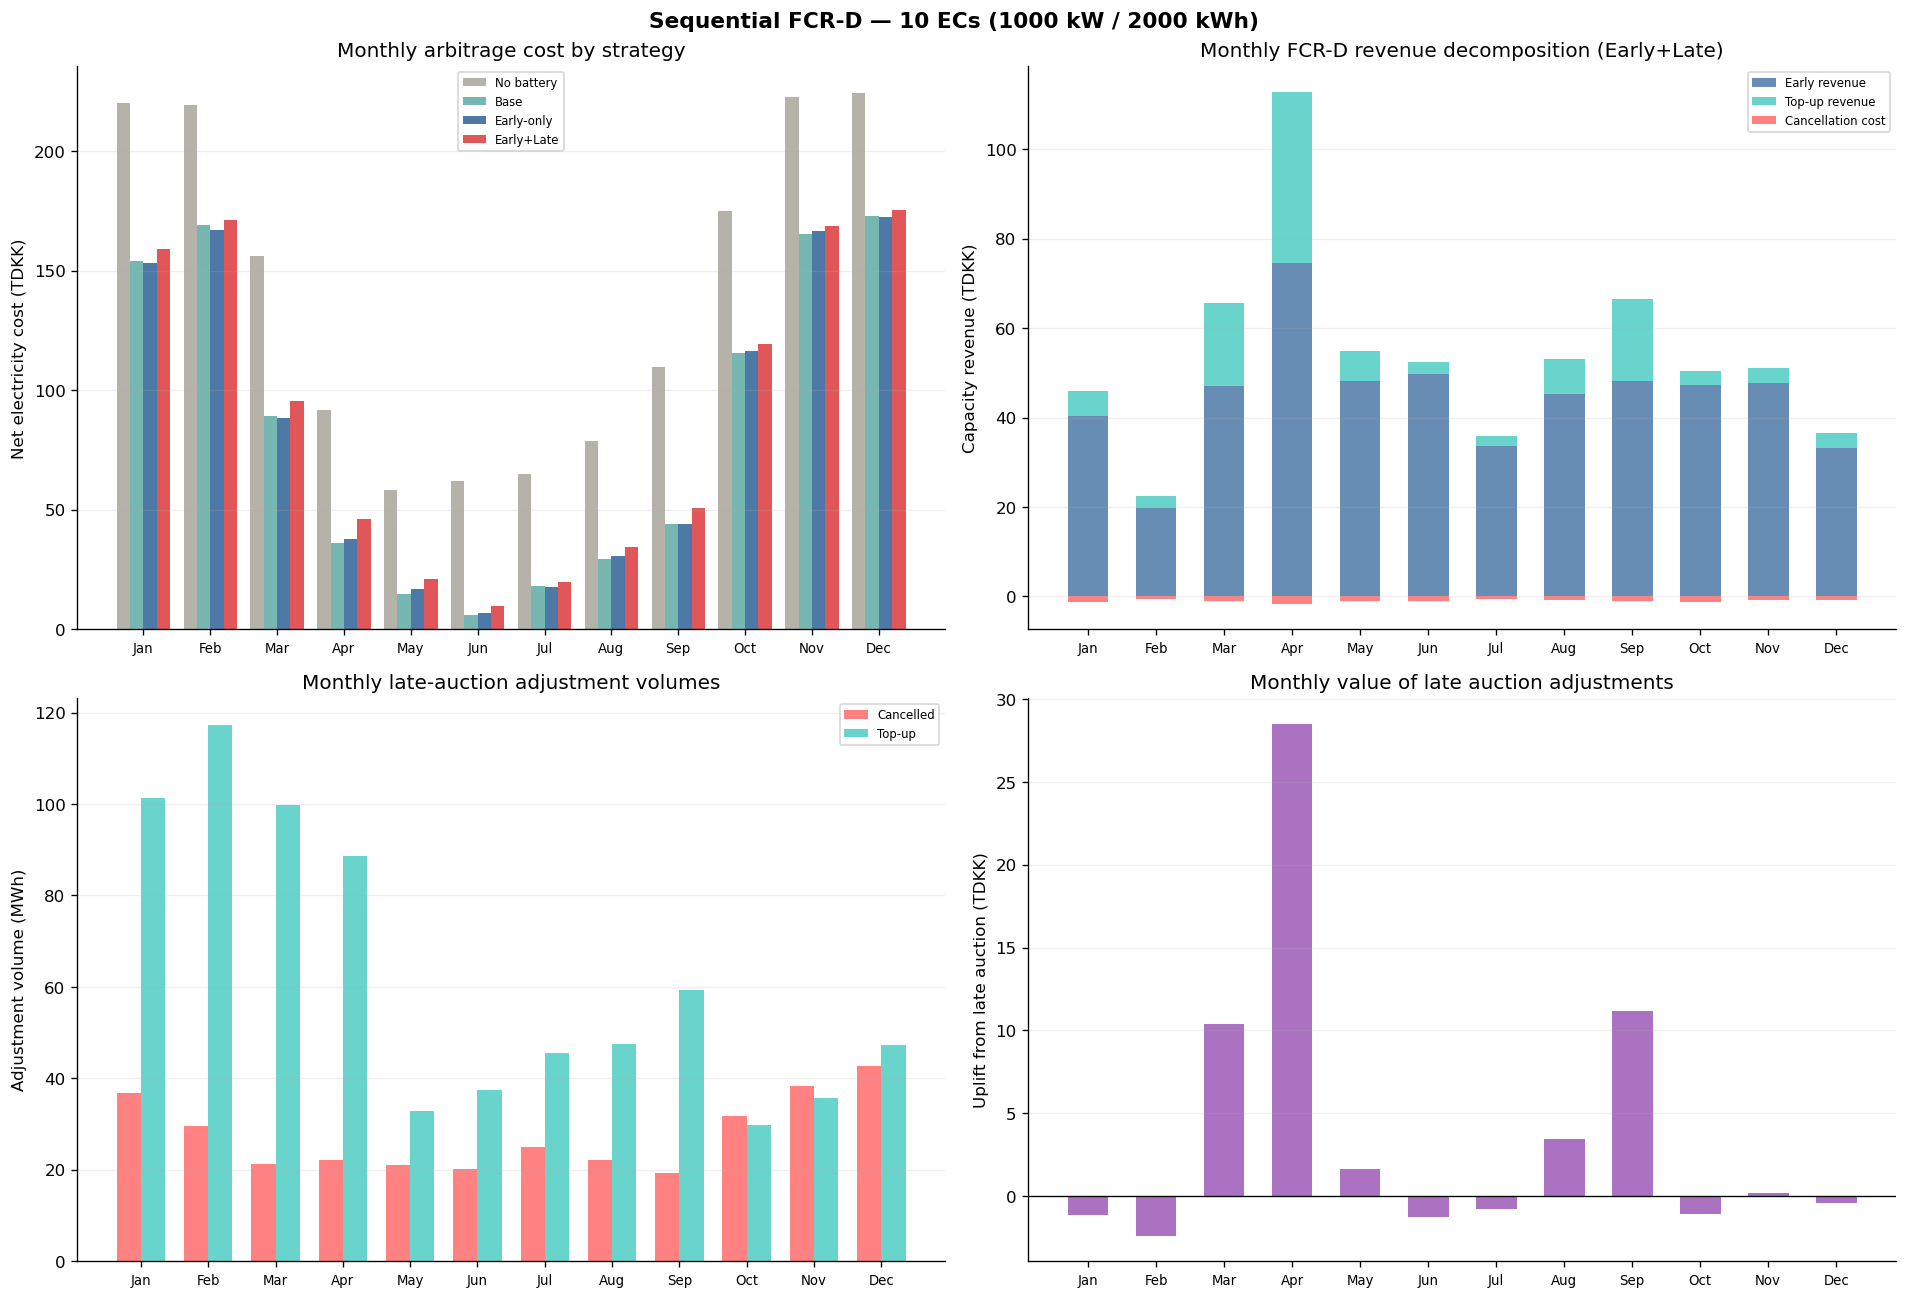

In [51]:
months  = list(range(1,13))
mnames  = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
x       = np.arange(12)

C_NO    = '#B4B2A9'; C_BAS = '#76B7B2'
C_EARLY = '#4E79A7'; C_LATE= '#E15759'
C_UP    = '#59A14F'; C_DN  = '#E15759'
C_TOP   = '#4ECDC4'; C_CANC= '#FF6B6B'
C_VAL   = '#9B59B6'

portfolio_base['no_bat_cost'] = (
    portfolio_base['buy_price']  * np.maximum(0, portfolio_base['D_agg'] - portfolio_base['PV_agg'])
  - portfolio_base['sell_price'] * np.maximum(0, portfolio_base['PV_agg'] - portfolio_base['D_agg']))

def by_month(df, col): return df.groupby('month')[col].sum().reindex(months, fill_value=0)/1000

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle(f'Sequential FCR-D — {N_ECS} ECs ({P_BAR_AGG:.0f} kW / {S_AGG:.0f} kWh)',
             fontsize=13, fontweight='bold')

# ── Panel 1: monthly arb cost (3 strategies) ─────────────────────────────────
ax = axes[0,0]
w3 = 0.2
ax.bar(x-w3*1.5, by_month(portfolio_base,  'no_bat_cost'),  w3, color=C_NO,    label='No battery')
ax.bar(x-w3*0.5, by_month(portfolio_base,  'arb_cost'),     w3, color=C_BAS,   label='Base')
ax.bar(x+w3*0.5, by_month(portfolio_early, 'arb_cost'),     w3, color=C_EARLY, label='Early-only')
ax.bar(x+w3*1.5, by_month(portfolio_late,  'arb_cost'),     w3, color=C_LATE,  label='Early+Late')
ax.set_xticks(x); ax.set_xticklabels(mnames, fontsize=8)
ax.set_ylabel('Net electricity cost (TDKK)')
ax.set_title('Monthly arbitrage cost by strategy')
ax.legend(fontsize=7); ax.grid(axis='y', alpha=0.2)
ax.spines[['top','right']].set_visible(False)

# ── Panel 2: capacity revenue decomposition ───────────────────────────────────
ax = axes[0,1]
m_e_rev = (by_month(portfolio_late,'rev_early_up') + by_month(portfolio_late,'rev_early_dn'))
m_topup = (by_month(portfolio_late,'rev_topup_up') + by_month(portfolio_late,'rev_topup_dn'))
m_canc  = (by_month(portfolio_late,'cost_cancel_up')+ by_month(portfolio_late,'cost_cancel_dn'))
ax.bar(x, m_e_rev, 0.6, color=C_EARLY, alpha=0.85, label='Early revenue')
ax.bar(x, m_topup, 0.6, bottom=m_e_rev, color=C_TOP, alpha=0.85, label='Top-up revenue')
ax.bar(x,-m_canc,  0.6, color=C_CANC,  alpha=0.85, label='Cancellation cost')
ax.set_xticks(x); ax.set_xticklabels(mnames, fontsize=8)
ax.set_ylabel('Capacity revenue (TDKK)')
ax.set_title('Monthly FCR-D revenue decomposition (Early+Late)')
ax.legend(fontsize=7); ax.grid(axis='y', alpha=0.2)
ax.spines[['top','right']].set_visible(False)

# ── Panel 3: adjustment volumes ───────────────────────────────────────────────
ax = axes[1,0]
m_cv = (by_month(portfolio_late,'cancel_up') + by_month(portfolio_late,'cancel_dn'))
m_tv = (by_month(portfolio_late,'topup_up' ) + by_month(portfolio_late,'topup_dn' ))
ax.bar(x-0.18, m_cv, 0.36, color=C_CANC, alpha=0.85, label='Cancelled')
ax.bar(x+0.18, m_tv, 0.36, color=C_TOP,  alpha=0.85, label='Top-up')
ax.set_xticks(x); ax.set_xticklabels(mnames, fontsize=8)
ax.set_ylabel('Adjustment volume (MWh)')
ax.set_title('Monthly late-auction adjustment volumes')
ax.legend(fontsize=7); ax.grid(axis='y', alpha=0.2)
ax.spines[['top','right']].set_visible(False)

# ── Panel 4: monthly value of late auction ────────────────────────────────────
ax = axes[1,1]
m_e_val = (by_month(portfolio_early,'rev_up') + by_month(portfolio_early,'rev_dn')
           - by_month(portfolio_early,'arb_cost'))
m_l_val = ((by_month(portfolio_late,'rev_total_up') + by_month(portfolio_late,'rev_total_dn'))
           - by_month(portfolio_late,'arb_cost'))
m_uplift = m_l_val - m_e_val
ax.bar(x, m_uplift, 0.6, color=C_VAL, alpha=0.85)
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(mnames, fontsize=8)
ax.set_ylabel('Uplift from late auction (TDKK)')
ax.set_title('Monthly value of late auction adjustments')
ax.grid(axis='y', alpha=0.2)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout(); plt.show()

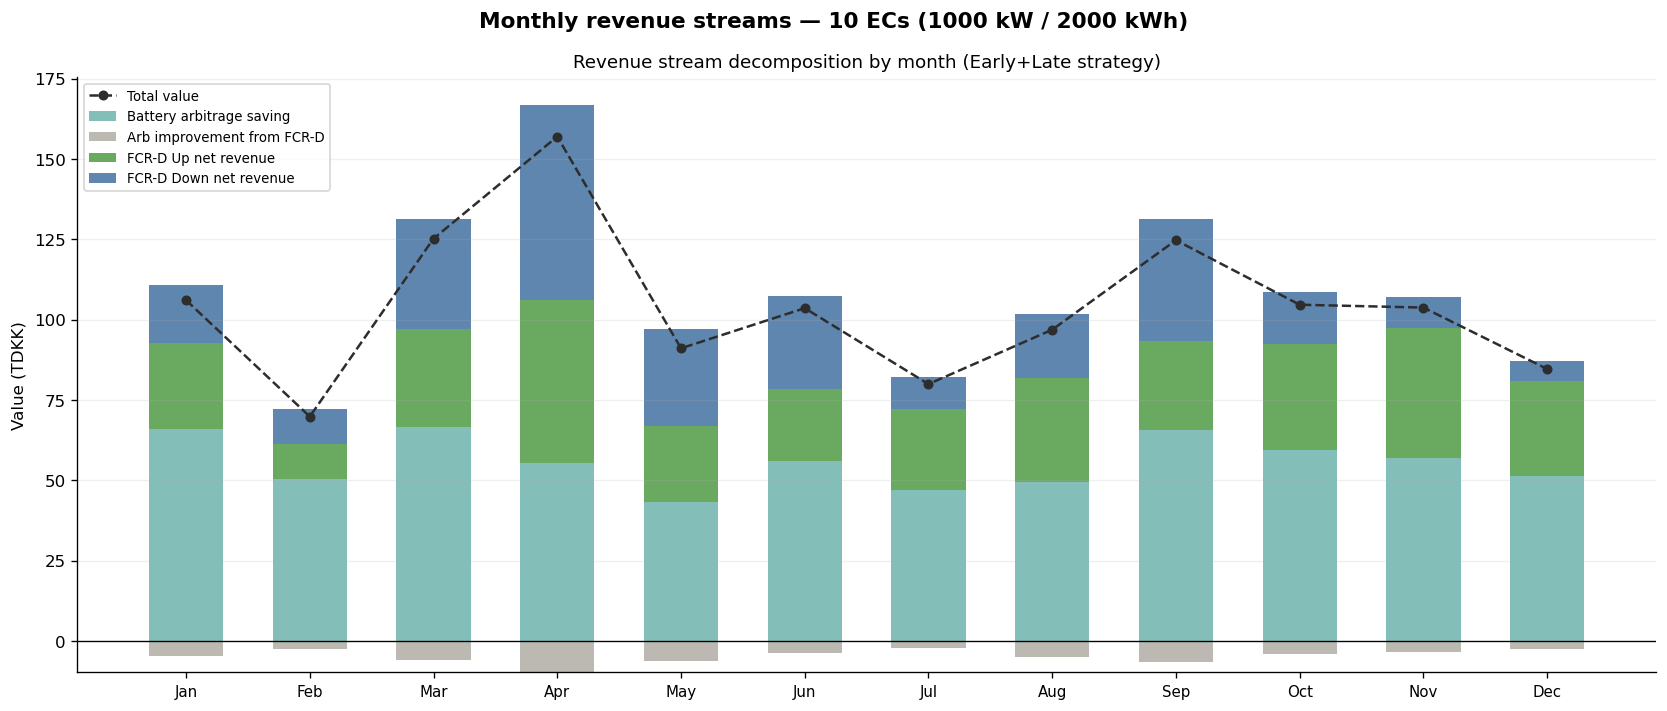

In [53]:
import numpy as np

# ── Split each stream into positive and negative parts ───────────────────────
def pos(s): return np.maximum(s, 0)
def neg(s): return np.minimum(s, 0)

streams = [m_bat_saving, m_arb_fcrd, m_fcrd_up, m_fcrd_dn]
colors  = [C_BAT, C_ARB, C_UP, C_DN]
labels  = ['Battery arbitrage saving', 'Arb improvement from FCR-D',
           'FCR-D Up net revenue', 'FCR-D Down net revenue']

fig, ax = plt.subplots(figsize=(14, 6))
fig.suptitle(
    f'Monthly revenue streams — {N_ECS} ECs ({P_BAR_AGG:.0f} kW / {S_AGG:.0f} kWh)',
    fontsize=13, fontweight='bold'
)

pos_bottom = np.zeros(12)
neg_bottom = np.zeros(12)

for s, c, lbl in zip(streams, colors, labels):
    p, n = pos(s.values), neg(s.values)
    ax.bar(x, p, bar_w, bottom=pos_bottom, color=c, alpha=0.9, label=lbl)
    ax.bar(x, n, bar_w, bottom=neg_bottom, color=c, alpha=0.9)  # no label duplicate
    pos_bottom += p
    neg_bottom += n

total = sum(streams)
ax.plot(x, total.values, 'o--', color='#2d2d2d', lw=1.5, markersize=5,
        zorder=5, label='Total value')

ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels(mnames, fontsize=9)
ax.set_ylabel('Value (TDKK)', fontsize=10)
ax.set_title('Revenue stream decomposition by month (Early+Late strategy)', fontsize=11)
ax.legend(fontsize=8, loc='upper left')
ax.grid(axis='y', alpha=0.2)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

In [54]:
# ── Yearly revenue stream summary ────────────────────────────────────────────
tot_bat   = m_bat_saving.sum()
tot_arb   = m_arb_fcrd.sum()
tot_up    = m_fcrd_up.sum()
tot_dn    = m_fcrd_dn.sum()
tot_total = tot_bat + tot_arb + tot_up + tot_dn

print(f'{"="*52}')
print(f'  Yearly revenue stream summary ({N_ECS} ECs)')
print(f'{"="*52}')
print(f'  {"Battery arbitrage saving":<35} {tot_bat:>8.1f} TDKK')
print(f'  {"Arb improvement from FCR-D":<35} {tot_arb:>8.1f} TDKK')
print(f'  {"FCR-D Up net revenue":<35} {tot_up:>8.1f} TDKK')
print(f'  {"FCR-D Down net revenue":<35} {tot_dn:>8.1f} TDKK')
print(f'{"─"*52}')
print(f'  {"Total value":<35} {tot_total:>8.1f} TDKK')
print(f'{"="*52}')
print(f'  {"FCR-D share of total":<35} {100*(tot_up+tot_dn+tot_arb)/tot_total:>7.1f} %')
print(f'  {"Battery arb share of total":<35} {100*tot_bat/tot_total:>7.1f} %')
print(f'{"="*52}')

  Yearly revenue stream summary (10 ECs)
  Battery arbitrage saving               668.0 TDKK
  Arb improvement from FCR-D             -56.2 TDKK
  FCR-D Up net revenue                   352.5 TDKK
  FCR-D Down net revenue                 283.2 TDKK
────────────────────────────────────────────────────
  Total value                           1247.5 TDKK
  FCR-D share of total                   46.5 %
  Battery arb share of total             53.5 %


## 13 — Interpretation

1. **Value of the late auction** — the headline metric. Positive when improved forecasts
   let the late program profitably shift capacity (top-ups in hours where late prices
   exceed early, cancellations where early bids were optimistic given true PV/demand).

2. **Cancellation vs top-up split** — if late bids mostly cancel, early forecasts
   over-bid (too aggressive given true SOC constraints). If mostly top-up, early
   forecasts were conservative. The mix depends on `EARLY_PV_NOISE_STD` and
   `EARLY_D_NOISE_STD`.

3. **Buyback cost asymmetry** — cancellations cost `max(early, late)` clearing price,
   so it is always cheaper to under-bid early and top-up late than to over-bid and
   cancel. This creates an implicit conservatism incentive in the early program.

4. **Sensitivity levers** — increase `EARLY_*_NOISE_STD` to grow the value of the
   late auction. Setting all noise to zero makes both programs see identical data;
   the late program then only benefits from actual early/late price differences.